# Analisis data polutan untuk mengetahui sumber polutan dan kualitas udara di kecamatan socah.

## 1. Business Understanding

### Tujuan

Proyek ini bertujuan untuk mengetahui dan menganalisis kondisi kualitas udara di wilayah kecamatan socah berdasarkan data beberapa polutan atmosfer. Polutan yang dianalisis meliputi CO, NO₂, HCHO, O₃, SO₂, dan CH₄.

Data dikumpulkan menggunakan data satelit Sentinel-5P melalui platform Copernicus Data Space Ecosystem. Wilayah pengambilan data dibatasi menggunakan koordinat geografis yang membentuk area penelitian Kabupaten Bangkalan.

Data yang diperoleh kemudian diolah menjadi data harian dan disimpan dalam format CSV untuk selanjutnya dianalisis dan divisualisasikan dalam bentuk grafik time series.

### Manfaat

Analisis ini bermanfaat untuk memberikan gambaran mengenai kondisi dan perubahan konsentrasi polutan udara di kecamatan socah selama periode pengamatan. Selain itu, hasil analisis dapat digunakan untuk:

* mengetahui pola perubahan konsentrasi polutan dari waktu ke waktu;
* mengetahui polutan yang memiliki nilai relatif tinggi atau rendah;
* mengidentifikasi adanya nilai yang tidak biasa atau outlier pada data;
* memberikan gambaran awal mengenai kemungkinan sumber polutan berdasarkan karakteristik masing-masing polutan; dan
* menjadi informasi pendukung untuk memahami kondisi lingkungan dan kualitas udara di wilayah Kabupaten Bangkalan.

### Wilayah dan Periode Penelitian

Wilayah penelitian dibatasi pada area kecamatan socah menggunakan polygon berdasarkan titik koordinat geografis.

Periode data yang digunakan adalah 31 Agustus 2025 sampai 1 September 2026, sehingga data mencakup sekurang-kurangnya satu tahun sampai dengan tanggal 31 Agustus 2026 sesuai dengan ketentuan tugas.


### A. AOI menggunakan koordinat

Pada tahap ini ditentukanArea of Interest (AOI) atau wilayah yang menjadi objek penelitian. AOI digunakan untuk membatasi data satelit agar data yang diambil hanya berasal dari wilayah penelitian.

Batas wilayah dibuat dalam bentuk Polygon GeoJSON yang terdiri dari beberapa titik koordinat longitude dan latitude. Setiap titik koordinat saling terhubung sehingga membentuk area penelitian.

Penggunaan AOI penting dalam proses crawling/pengambilan data karena data Sentinel-5P memiliki cakupan wilayah yang luas. Dengan adanya AOI, data yang dianalisis dapat difokuskan pada wilayah kecamatan socah.

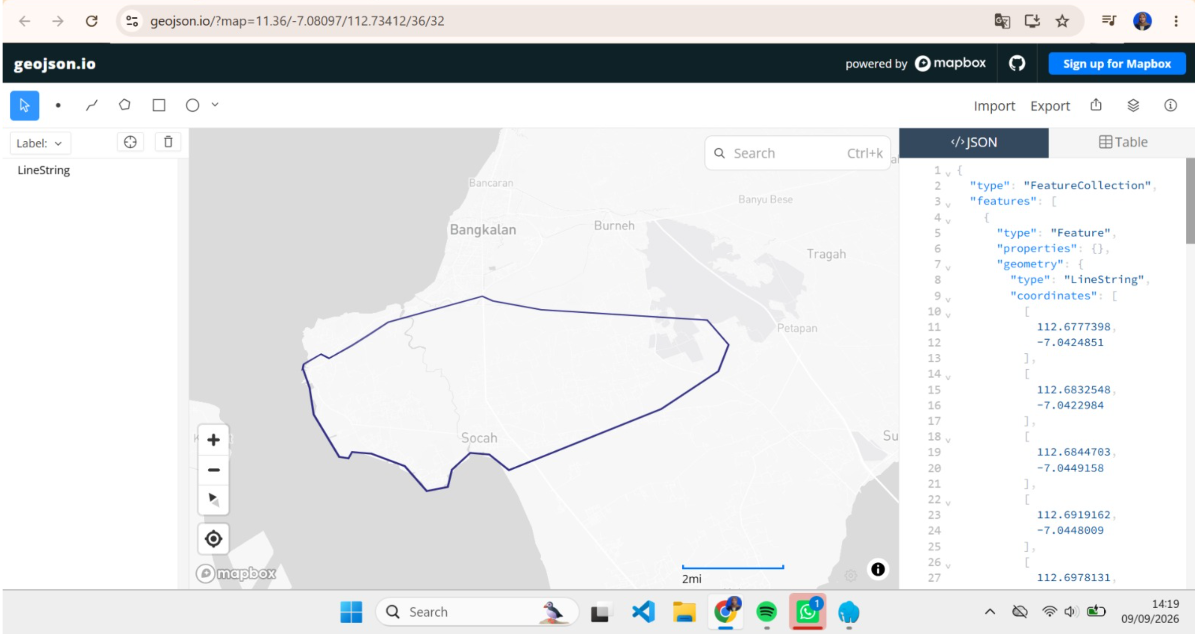

In [ ]:
aoi = {
    "type": "Polygon",
    "coordinates": [[
        [112.6777398, -7.0424851],
        [112.6832548, -7.0422984],
        [112.6844703, -7.0449158],
        [112.6919162, -7.0448009],
        [112.6978131, -7.0443554],
        [112.7044056, -7.0437135],
        [112.7322089, -7.0519494],
        [112.7338484, -7.0553321],
        [112.7436958, -7.0664444],
        [112.7813151, -7.0982549],
        [112.7802849, -7.1082567],
        [112.77158, -7.1130475],
        [112.7505384, -7.1126806],
        [112.7066489, -7.1031109],
        [112.7049915, -7.0964851],
        [112.7011739, -7.0931536],
        [112.6947213, -7.0943709],
        [112.6913741, -7.0977583],
        [112.6864452, -7.0955771],
        [112.6853486, -7.0863602],
        [112.6800101, -7.0781829],
        [112.6761070, -7.0747781],
        [112.6745279, -7.0758499],
        [112.6727385, -7.0740676],
        [112.6728907, -7.0587783],
        [112.6756963, -7.0504549],
        [112.6768774, -7.0438908],
        [112.6766972, -7.0438595],
        [112.6777336, -7.0424716],
        [112.6771448, -7.0432653],
        [112.6768899, -7.0436477],
    ]]
}

In [ ]:
!pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.8 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
import openeo

connection = openeo.connect(
    "https://openeo.dataspace.copernicus.eu"
)

connection.authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=QEGX-RDFI 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

### B. Crawling Data Polutan Kecamatan Socah Menggunakan Sentinel-5P

Kode tersebut digunakan untuk mengambil (crawling) data polutan udara di Kecamatan Socah menggunakan data Sentinel-5P melalui openEO. Data yang diambil terdiri dari enam jenis polutan, yaitu CO, NO₂, HCHO, O₃, SO₂, dan CH₄.

kemudian menggabungkannya menjadi satu file CSV untuk digunakan pada tahap preprocessing dan ekstraksi fitur TSFEL.

In [ ]:
!pip install netCDF4
import pandas as pd
import netCDF4
import numpy as np
import time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 56.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import netCDF4
import openeo
import time
import os

# ==================================================
# 1. KONFIGURASI
# ==================================================

POLLUTANTS = ["CO", "NO2", "HCHO", "O3", "SO2", "CH4"]

spatial_extent = {
    "west": 112.6723173,
    "south": -7.2158838,
    "east": 113.0724605,
    "north": -6.9302456
}

START_DATE = "2025-08-31"
END_DATE = "2026-09-01"

OUTPUT_DIR = "hasil_socah"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FINAL_FILE = os.path.join(
    OUTPUT_DIR, "pollutant_data_socah.csv"
)

# ==================================================
# 2. AUTENTIKASI
# ==================================================

def buat_koneksi():
    print("Menghubungkan ke Copernicus...")
    conn = openeo.connect(
        "https://openeo.dataspace.copernicus.eu"
    ).authenticate_oidc()
    print("Autentikasi berhasil.")
    return conn

connection = buat_koneksi()


# ==================================================
# 3. MEMBACA FILE NETCDF
# ==================================================

def baca_nc(file_path, polutan):
    with netCDF4.Dataset(file_path) as ds:

        if "t" not in ds.variables:
            raise ValueError("Variabel waktu 't' tidak ditemukan.")

        if polutan not in ds.variables:
            raise ValueError(
                f"Variabel {polutan} tidak ditemukan di NetCDF."
            )

        time_var = ds.variables["t"]

        dates = netCDF4.num2date(
            time_var[:],
            units=time_var.units,
            calendar=getattr(time_var, "calendar", "standard")
        )

        dates = pd.to_datetime([
            str(date)[:10] for date in dates
        ])

        values = np.ma.filled(
            np.ma.asarray(ds.variables[polutan][:]),
            np.nan
        ).squeeze()

        values = np.asarray(values, dtype=float)

        if values.ndim != 1 or len(values) != len(dates):
            raise ValueError(
                f"Dimensi data {polutan} tidak sesuai: "
                f"{values.shape}"
            )

        return pd.DataFrame({
            "date": dates,
            polutan: values
        })


# ==================================================
# 4. PENYIMPANAN DATA SEMENTARA
# ==================================================

def simpan_sementara(data, polutan):
    file_csv = os.path.join(
        OUTPUT_DIR, f"{polutan}_Socah.csv"
    )

    data.to_csv(file_csv, index=False)
    print(f"Checkpoint {polutan} tersimpan: {file_csv}")


def baca_sementara(polutan):
    file_csv = os.path.join(
        OUTPUT_DIR, f"{polutan}_Socah.csv"
    )

    if os.path.exists(file_csv):
        data = pd.read_csv(file_csv)

        if "date" in data.columns and polutan in data.columns:
            data["date"] = pd.to_datetime(data["date"])
            print(f"Memakai data tersimpan: {polutan}")
            return data

    return None


# ==================================================
# 5. MENGAMBIL DATA SATU POLUTAN
# ==================================================

def ambil_polutan(polutan, max_retry=5):
    global connection

    file_nc = os.path.join(
        OUTPUT_DIR, f"{polutan}_Socah.nc"
    )

    # Gunakan data yang sudah berhasil disimpan
    data_lama = baca_sementara(polutan)
    if data_lama is not None:
        return data_lama

    for percobaan in range(1, max_retry + 1):
        try:
            print(
                f"\nMengambil {polutan} "
                f"(percobaan {percobaan}/{max_retry})"
            )

            s5post = connection.load_collection(
                "SENTINEL_5P_L2",
                temporal_extent=[START_DATE, END_DATE],
                spatial_extent=spatial_extent,
                bands=[polutan]
            )

            s5p_daily = s5post.aggregate_temporal_period(
                reducer="mean",
                period="day"
            )

            s5p_aoi = s5p_daily.aggregate_spatial(
                reducer="mean",
                geometries=aoi
            )

            job = s5p_aoi.execute_batch(
                title=f"{polutan} Kecamatan Socah",
                outputfile=file_nc
            )

            print("Job dibuat, menunggu proses selesai...")
            job.start_and_wait()

            if not os.path.exists(file_nc):
                raise FileNotFoundError(
                    f"File {file_nc} tidak ditemukan."
                )

            data = baca_nc(file_nc, polutan)

            if data.empty:
                raise ValueError(
                    f"Data {polutan} kosong."
                )

            # Simpan langsung setelah berhasil
            simpan_sementara(data, polutan)

            print(f"{polutan} berhasil diambil.")
            return data

        except Exception as e:
            error = str(e)
            print(f"Error {polutan}: {error}")

            # Kredit tidak cukup: berhenti agar tidak
            # menghabiskan percobaan tanpa hasil.
            if "402" in error or "PaymentRequired" in error:
                raise RuntimeError(
                    f"Kredit tidak mencukupi untuk {polutan}. "
                    "Periksa kredit Copernicus, lalu jalankan "
                    "ulang kode setelah masalah diselesaikan."
                ) from e

            # Autentikasi perlu diperbarui
            if (
                "401" in error
                or "TokenValidationFailure" in error
            ):
                if percobaan == max_retry:
                    raise

                print("Memperbarui autentikasi...")
                time.sleep(30)

                connection = buat_koneksi()
                continue

            # Gangguan sementara pada server
            if any(
                kode in error
                for kode in ["502", "503", "504", "Bad Gateway"]
            ):
                if percobaan < max_retry:
                    jeda = 30 * percobaan
                    print(
                        f"Gangguan server. "
                        f"Mencoba lagi dalam {jeda} detik."
                    )
                    time.sleep(jeda)
                    continue

            # Kesalahan lain tidak boleh disembunyikan
            raise

    raise RuntimeError(f"Data {polutan} belum berhasil diperoleh.")


# ==================================================
# 6. MENGAMBIL SEMUA POLUTAN
# ==================================================

data_polutan = {}

for polutan in POLLUTANTS:
    print(f"\n{'=' * 45}")
    print(f"MEMPROSES POLUTAN {polutan}")
    print(f"{'=' * 45}")

    data_polutan[polutan] = ambil_polutan(
        polutan,
        max_retry=5
    )

    print(f"Polutan {polutan} selesai.")
    time.sleep(30)


# ==================================================
# 7. VALIDASI SEMUA POLUTAN
# ==================================================

kolom_berhasil = list(data_polutan.keys())
kolom_gagal = [
    p for p in POLLUTANTS
    if p not in data_polutan
]

if kolom_gagal:
    raise RuntimeError(
        f"Data belum lengkap. Polutan yang belum tersedia: "
        f"{kolom_gagal}"
    )

# ==================================================
# 8. PENGGABUNGAN SEMUA DATA
# ==================================================

df = None

for polutan in POLLUTANTS:
    data = data_polutan[polutan]

    if df is None:
        df = data.copy()
    else:
        df = df.merge(
            data,
            on="date",
            how="outer",
            validate="one_to_one"
        )

df = df.sort_values("date").reset_index(drop=True)
df = df[["date"] + POLLUTANTS]

# ==================================================
# 9. SIMPAN HASIL AKHIR
# ==================================================

if len(df.columns) != 7:
    raise ValueError("Jumlah kolom hasil tidak sesuai.")

df.to_csv(FINAL_FILE, index=False)

print("\nSEMUA POLUTAN BERHASIL DIPROSES")
print("File akhir:", FINAL_FILE)
print("Jumlah baris:", len(df))
print("Tanggal pertama:", df["date"].min())
print("Tanggal terakhir:", df["date"].max())
print("\nJumlah missing value:")
print(df.isna().sum())

Menghubungkan ke Copernicus...
Authenticated using refresh token.
Autentikasi berhasil.

MEMPROSES POLUTAN CO

Mengambil CO (percobaan 1/5)
0:00:00 Job 'j-2610031533254e3f9e94e2009f2d1126': send 'start'
0:00:01 Job 'j-2610031533254e3f9e94e2009f2d1126': queued (progress 0%)
0:00:07 Job 'j-2610031533254e3f9e94e2009f2d1126': queued (progress 0%)
0:00:13 Job 'j-2610031533254e3f9e94e2009f2d1126': queued (progress 0%)
0:00:21 Job 'j-2610031533254e3f9e94e2009f2d1126': queued (progress 0%)
0:00:31 Job 'j-2610031533254e3f9e94e2009f2d1126': queued (progress 0%)
0:00:43 Job 'j-2610031533254e3f9e94e2009f2d1126': queued (progress 0%)
0:00:59 Job 'j-2610031533254e3f9e94e2009f2d1126': running (progress N/A)
0:01:18 Job 'j-2610031533254e3f9e94e2009f2d1126': running (progress N/A)
0:01:42 Job 'j-2610031533254e3f9e94e2009f2d1126': running (progress N/A)
0:02:12 Job 'j-2610031533254e3f9e94e2009f2d1126': running (progress N/A)
0:02:50 Job 'j-2610031533254e3f9e94e2009f2d1126': running (progress N/A)
0:03:3

## 2. Data Understanding

Tahap Data Understanding dilakukan untuk memahami karakteristik data polutan yang telah diperoleh dari wilayah kecamatan socah.

Eksplorasi dilakukan terhadap seluruh polutan dengan beberapa pemeriksaan, yaitu:

1. Struktur data, untuk mengetahui jumlah data, nama kolom, tipe data, dan contoh isi data.
2. Statistik deskriptif, untuk mengetahui nilai minimum, maksimum, rata-rata, median, dan penyebaran data.
3. Missing value, untuk mengetahui apakah terdapat data yang kosong.
4. Outlier, untuk mengetahui apakah terdapat nilai yang berbeda jauh dari sebagian besar pengamatan.
5. Rentang waktu, untuk memastikan data mencakup periode penelitian.
6. Pola data, yang selanjutnya akan diamati melalui grafik time series.

Eksplorasi ini dilakukan untuk mengetahui apakah terdapat data yang tidak lengkap atau data yang memiliki karakteristik tidak biasa sebelum dilakukan analisis lebih lanjut.


In [ ]:
def data_understanding(
    file_path,
    variable_name
):

    print("\n")
    print("=" * 70)
    print(f"DATA UNDERSTANDING - {variable_name}")
    print("=" * 70)

    df = pd.read_csv(file_path)

    df["date"] = pd.to_datetime(df["date"])

    # 1. Struktur dan isi data
    print("\n1. Struktur Data")
    print("-" * 40)

    print(df.info())

    print("\n5 data pertama:")
    print(df.head())

    print("\n5 data terakhir:")
    print(df.tail())

    # 2. Statistik deskriptif
    print("\n2. Statistik Deskriptif")
    print("-" * 40)

    print(
        df[variable_name].describe()
    )

    # 3. Missing value
    print("\n3. Missing Value")
    print("-" * 40)

    print(
        "Jumlah missing:",
        df[variable_name].isna().sum()
    )

    print(
        "Persentase missing:",
        round(
            df[variable_name].isna().mean() * 100,
            2
        ),
        "%"
    )

    # 4. Missing tanggal
    print("\n4. Missing Date")
    print("-" * 40)

    full_range = pd.date_range(
        start="2025-08-31",
        end="2026-08-31",
        freq="D"
    )

    missing_dates = full_range.difference(
        df["date"]
    )

    print(
        "Jumlah tanggal missing:",
        len(missing_dates)
    )

    if len(missing_dates) > 0:
        print("Tanggal missing:")
        print(missing_dates)

    # 5. Outlier menggunakan IQR
    print("\n5. Outlier - Metode IQR")
    print("-" * 40)

    Q1 = df[variable_name].quantile(0.25)
    Q3 = df[variable_name].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[variable_name] < lower_bound) |
        (df[variable_name] > upper_bound)
    ]

    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)

    print("Batas bawah:", lower_bound)
    print("Batas atas:", upper_bound)

    print(
        "Jumlah outlier:",
        len(outliers)
    )

    if len(outliers) > 0:
        print("\nData outlier:")
        print(
            outliers[
                ["date", variable_name]
            ]
        )

    return df, outliers, lower_bound, upper_bound

### 2.1 Data Understanding untuk CO

Pada tahap ini dilakukan eksplorasi terhadap data CO kecamatan socah.

Analisis meliputi struktur data, statistik deskriptif, missing value, serta deteksi outlier menggunakan metode IQR (Interquartile Range).

Hasil eksplorasi digunakan untuk mengetahui karakteristik nilai CO selama periode pengamatan dan mengetahui apakah terdapat nilai yang tidak biasa.


In [ ]:
co_df, co_outliers, co_lower, co_upper = data_understanding(
    "hasil_socah/CO_Socah.csv",
    "CO"
)



DATA UNDERSTANDING - CO

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    219 non-null    datetime64[ns]
 1   CO      219 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.6 KB
None

5 data pertama:
        date        CO
0 2025-08-31  0.028127
1 2025-09-01  0.026580
2 2025-09-02  0.023676
3 2025-09-03  0.022243
4 2025-09-04  0.028168

5 data terakhir:
          date        CO
214 2026-08-26  0.027798
215 2026-08-27  0.029471
216 2026-08-28  0.035424
217 2026-08-29  0.038260
218 2026-08-30  0.034129

2. Statistik Deskriptif
----------------------------------------
count    219.000000
mean       0.029033
std        0.003491
min        0.020330
25%        0.026721
50%        0.028610
75%        0.031198
max        0.046483
Name: CO, dtype: float

### 2.2 Data Understanding NO₂

Data NO₂ Kabupaten Bangkalan dianalisis untuk mengetahui struktur, statistik deskriptif, kelengkapan data, dan kemungkinan adanya outlier.

Hasil pemeriksaan digunakan untuk memahami karakteristik perubahan nilai NO₂ selama periode satu tahun.


In [ ]:
no2_df, no2_outliers, no2_lower, no2_upper = data_understanding(
    "hasil_socah/NO2_Socah.csv",
    "NO2"
)



DATA UNDERSTANDING - NO2

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    184 non-null    datetime64[ns]
 1   NO2     184 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.0 KB
None

5 data pertama:
        date       NO2
0 2025-08-31 -0.000010
1 2025-09-02  0.000012
2 2025-09-03  0.000010
3 2025-09-04  0.000006
4 2025-09-05  0.000024

5 data terakhir:
          date       NO2
179 2026-08-25  0.000024
180 2026-08-27  0.000036
181 2026-08-28  0.000044
182 2026-08-29  0.000038
183 2026-08-31  0.000031

2. Statistik Deskriptif
----------------------------------------
count    184.000000
mean       0.000035
std        0.000028
min       -0.000010
25%        0.000024
50%        0.000031
75%        0.000040
max        0.000317
Name: NO2, dtype: flo

### 2.3 Data Understanding HCHO

Eksplorasi dilakukan terhadap data HCHO Kabupaten Bangkalan untuk mengetahui karakteristik data, statistik deskriptif, missing value, serta nilai yang terindikasi sebagai outlier.


In [ ]:
hcho_df, hcho_outliers, hcho_lower, hcho_upper = data_understanding(
    "hasil_socah/HCHO_Socah.csv",
    "HCHO"
)



DATA UNDERSTANDING - HCHO

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    245 non-null    datetime64[ns]
 1   HCHO    245 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.0 KB
None

5 data pertama:
        date      HCHO
0 2025-08-31  0.000074
1 2025-09-01  0.000139
2 2025-09-02  0.000061
3 2025-09-03  0.000035
4 2025-09-04 -0.000142

5 data terakhir:
          date      HCHO
240 2026-08-26  0.000292
241 2026-08-27  0.000164
242 2026-08-28  0.000138
243 2026-08-29  0.000156
244 2026-08-31  0.000094

2. Statistik Deskriptif
----------------------------------------
count    245.000000
mean       0.000162
std        0.000118
min       -0.000257
25%        0.000089
50%        0.000158
75%        0.000228
max        0.000657
Name: HCHO, dtype: f

### 2.4 Data Understanding O₃

Eksplorasi data O₃ dilakukan untuk mengetahui karakteristik nilai O₃ selama periode penelitian, termasuk statistik deskriptif, kelengkapan data, dan kemungkinan adanya nilai yang tidak biasa.


In [ ]:
o3_df, o3_outliers, o3_lower, o3_upper = data_understanding(
    "hasil_socah/O3_Socah.csv",
    "O3"
)



DATA UNDERSTANDING - O3

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    354 non-null    datetime64[ns]
 1   O3      354 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.7 KB
None

5 data pertama:
        date        O3
0 2025-08-31  0.114844
1 2025-09-01  0.115109
2 2025-09-02  0.112202
3 2025-09-03  0.113420
4 2025-09-04  0.112663

5 data terakhir:
          date        O3
349 2026-08-27  0.117693
350 2026-08-28  0.116794
351 2026-08-29  0.115855
352 2026-08-30  0.113462
353 2026-08-31  0.115889

2. Statistik Deskriptif
----------------------------------------
count    354.000000
mean       0.115731
std        0.002314
min        0.109655
25%        0.114087
50%        0.115554
75%        0.117273
max        0.123087
Name: O3, dtype: float

### 2.5 Data Understanding SO₂

Data SO₂ Kabupaten Bangkalan diperiksa untuk mengetahui struktur data, statistik deskriptif, missing value, serta kemungkinan adanya outlier selama periode pengamatan.


In [ ]:
so2_df, so2_outliers, so2_lower, so2_upper = data_understanding(
    "hasil_socah/SO2_Socah.csv",
    "SO2"
)



DATA UNDERSTANDING - SO2

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    236 non-null    datetime64[ns]
 1   SO2     236 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.8 KB
None

5 data pertama:
        date       SO2
0 2025-08-31 -0.000114
1 2025-09-01 -0.000081
2 2025-09-02  0.000038
3 2025-09-03  0.000112
4 2025-09-04  0.000126

5 data terakhir:
          date       SO2
231 2026-08-26 -0.000121
232 2026-08-27  0.000062
233 2026-08-28  0.000325
234 2026-08-29 -0.000077
235 2026-08-31  0.000078

2. Statistik Deskriptif
----------------------------------------
count    236.000000
mean       0.000049
std        0.000228
min       -0.000870
25%       -0.000071
50%        0.000049
75%        0.000167
max        0.000808
Name: SO2, dtype: flo

### 2.6. Data Understanding CH₄

Data CH₄ Kabupaten Bangkalan dieksplorasi untuk mengetahui karakteristik data, statistik deskriptif, kelengkapan data, dan kemungkinan adanya nilai yang tidak biasa selama periode penelitian.


In [ ]:
ch4_df, ch4_outliers, ch4_lower, ch4_upper = data_understanding(
    "hasil_socah/CH4_Socah.csv",
    "CH4"
)



DATA UNDERSTANDING - CH4

1. Struktur Data
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    14 non-null     datetime64[ns]
 1   CH4     14 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 356.0 bytes
None

5 data pertama:
        date          CH4
0 2026-06-06  1881.687378
1 2026-06-07  1853.463135
2 2026-06-08  1884.832479
3 2026-06-11  1904.337240
4 2026-06-19  1829.310099

5 data terakhir:
         date          CH4
9  2026-07-09  1913.532227
10 2026-07-20  1901.123413
11 2026-07-24  1906.912354
12 2026-08-17  1888.164978
13 2026-08-27  1881.554810

2. Statistik Deskriptif
----------------------------------------
count      14.000000
mean     1888.702382
std        23.046410
min      1829.310099
25%      1882.473653
50%      1892.029724
75%      1905.165517
m

## 3. Grafik Time Series

Tahap berikutnya adalah memvisualisasikan data dalam bentuk grafik time series.

Grafik time series digunakan untuk melihat perubahan nilai masing-masing polutan berdasarkan tanggal selama periode 31 Agustus 2025 sampai 31 Agustus 2026.

Melalui grafik ini dapat diamati pola perubahan konsentrasi polutan, seperti kecenderungan meningkat, menurun, relatif stabil, atau mengalami lonjakan pada waktu tertentu.




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_time_series(df, polutan):
    plt.figure(figsize=(15, 5))

    plt.plot(df["date"], df[polutan], linewidth=1)

    plt.title(f"Time Series Polutan {polutan} Kecamatan Socah")
    plt.xlabel("Tanggal")
    plt.ylabel(f"Nilai {polutan}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

df_co = df[["date", "CO"]].dropna()
df_no2 = df[["date", "NO2"]].dropna()
df_hcho = df[["date", "HCHO"]].dropna()
df_o3 = df[["date", "O3"]].dropna()
df_so2 = df[["date", "SO2"]].dropna()
df_ch4 = df[["date", "CH4"]].dropna()

### 3.1 Grafik CO

Time Series CO Kabupaten Bangkalan

Grafik berikut menunjukkan perubahan nilai CO dari waktu ke waktu selama periode pengamatan. Grafik digunakan untuk melihat pola dan fluktuasi CO di wilayah Kabupaten Bangkalan.


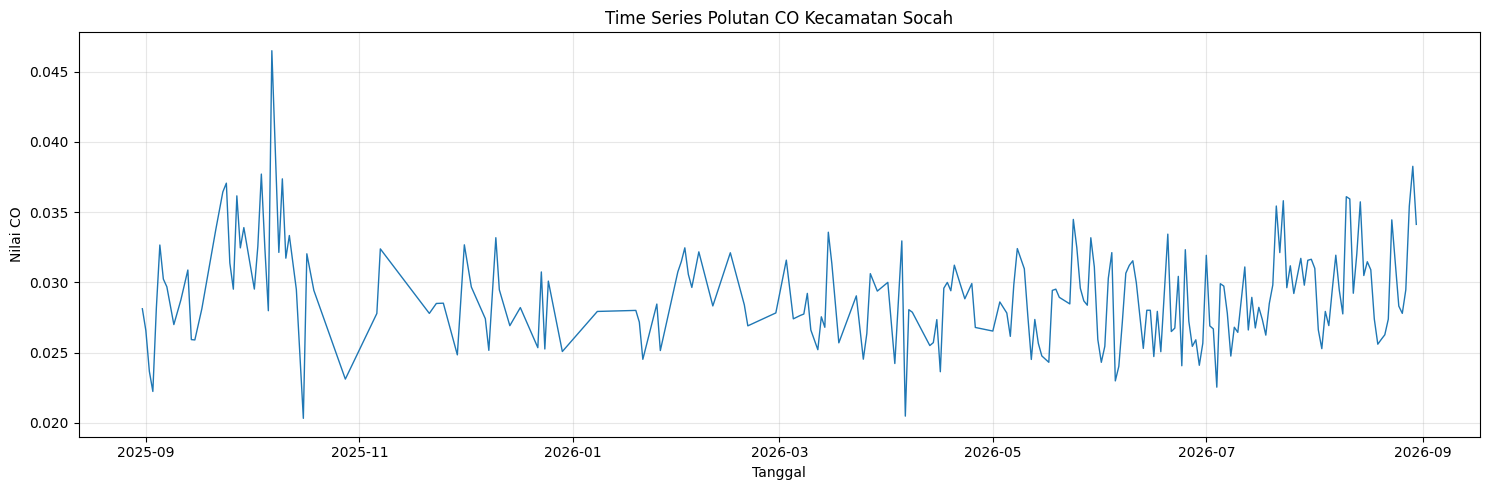

In [ ]:
plot_time_series(
    df_co,
    "CO"
)

### 3.2 Grafik NO₂

Time Series NO₂ Kabupaten Bangkalan

Grafik menunjukkan perubahan nilai NO₂ harian selama periode penelitian. Pola naik dan turun pada grafik dapat digunakan untuk melihat perubahan konsentrasi NO₂ dari waktu ke waktu.


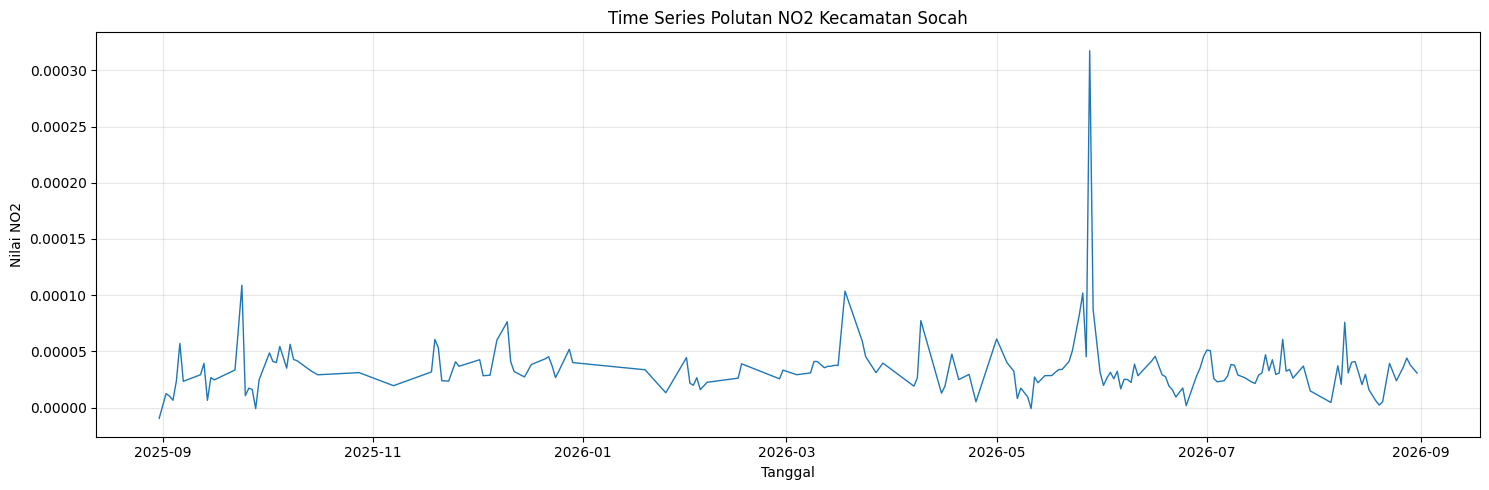

In [ ]:
plot_time_series(
    no2_df,
    "NO2"
)

### 3.3 Grafik HCHO
Time Series HCHO Kabupaten Bangkalan

Grafik menunjukkan perubahan nilai HCHO selama periode pengamatan dan digunakan untuk melihat pola fluktuasi HCHO berdasarkan waktu.


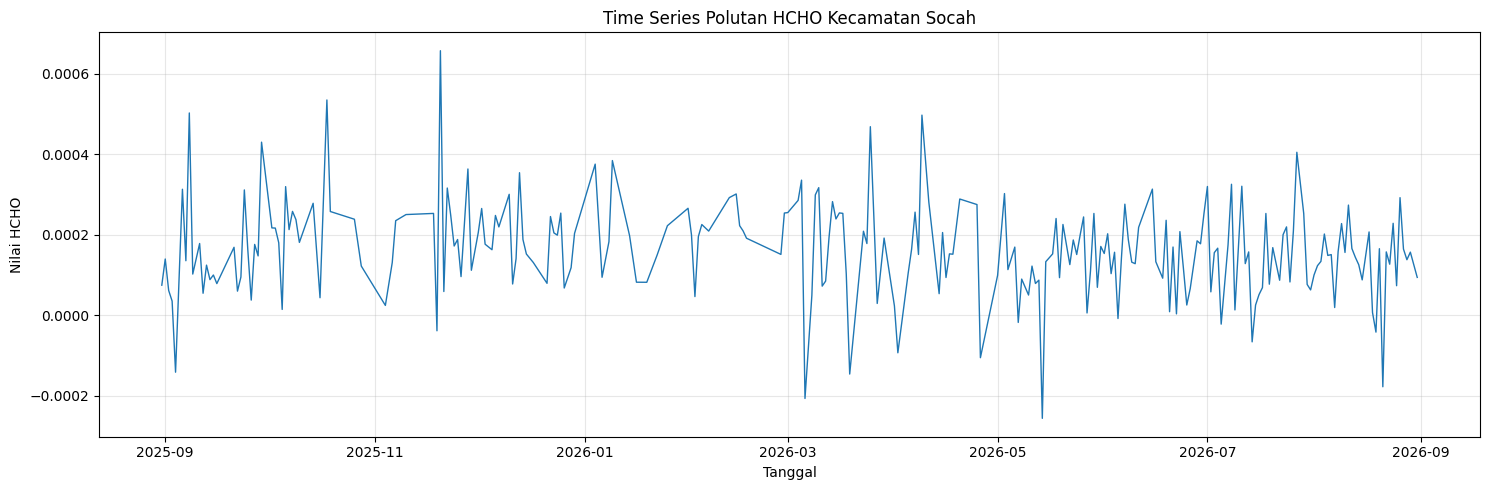

In [ ]:
plot_time_series(
    hcho_df,
    "HCHO"
)

### 3.4 Grafik O₃

Time Series O₃ Kabupaten Bangkalan

Grafik digunakan untuk melihat perubahan nilai O₃ dari waktu ke waktu selama periode penelitian dan mengidentifikasi pola fluktuasinya.


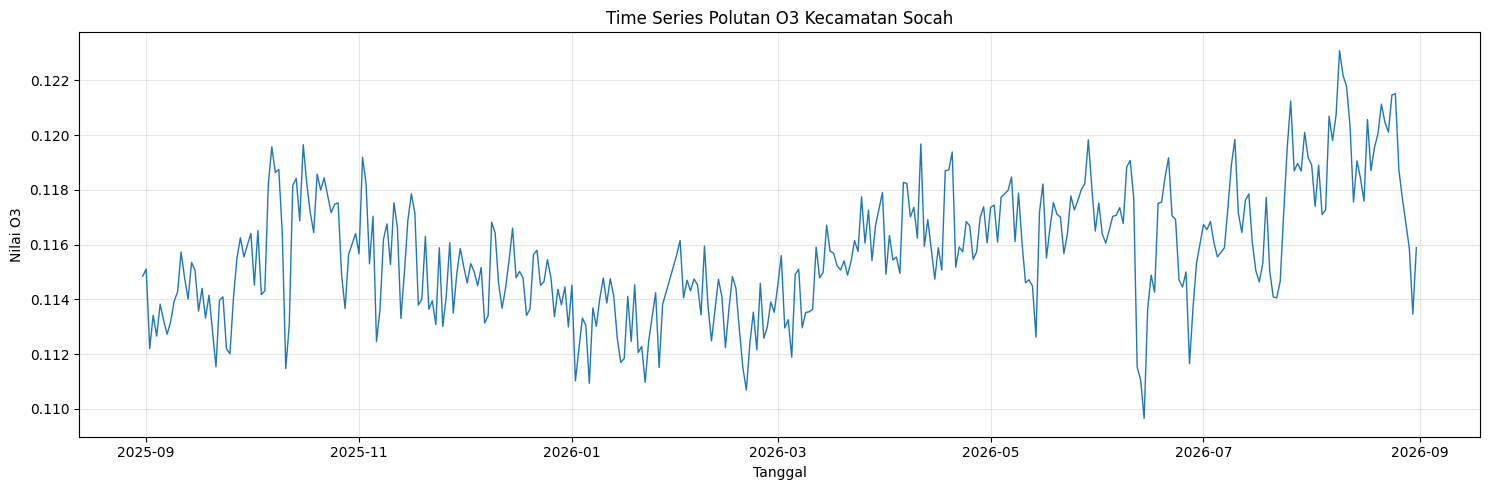

In [ ]:
plot_time_series(
    o3_df,
    "O3"
)

### 3.5 Grafik SO₂

Time Series SO₂ Kabupaten Bangkalan

Grafik menunjukkan perubahan nilai SO₂ selama periode pengamatan sehingga dapat diamati pola naik-turun nilai SO₂ dari waktu ke waktu.


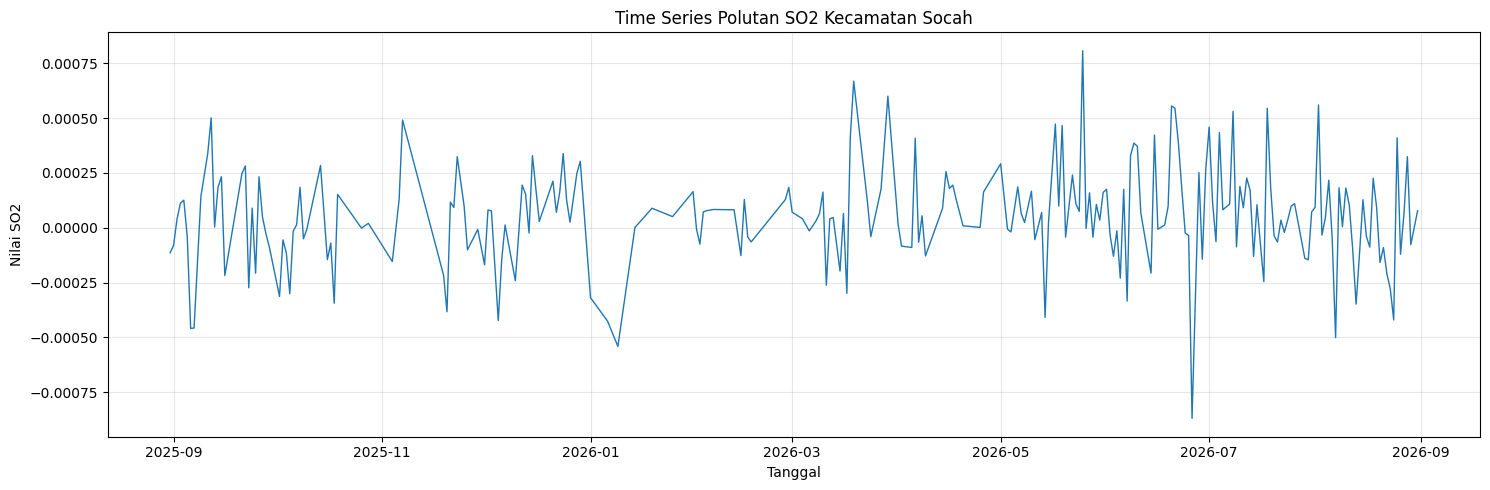

In [ ]:
plot_time_series(
    so2_df,
    "SO2"
)

### 3.6 Grafik CH₄

Time Series CH₄ Kabupaten Bangkalan

Grafik menunjukkan perubahan nilai CH₄ selama periode penelitian dan digunakan untuk mengamati pola serta fluktuasi nilai CH₄ berdasarkan waktu.


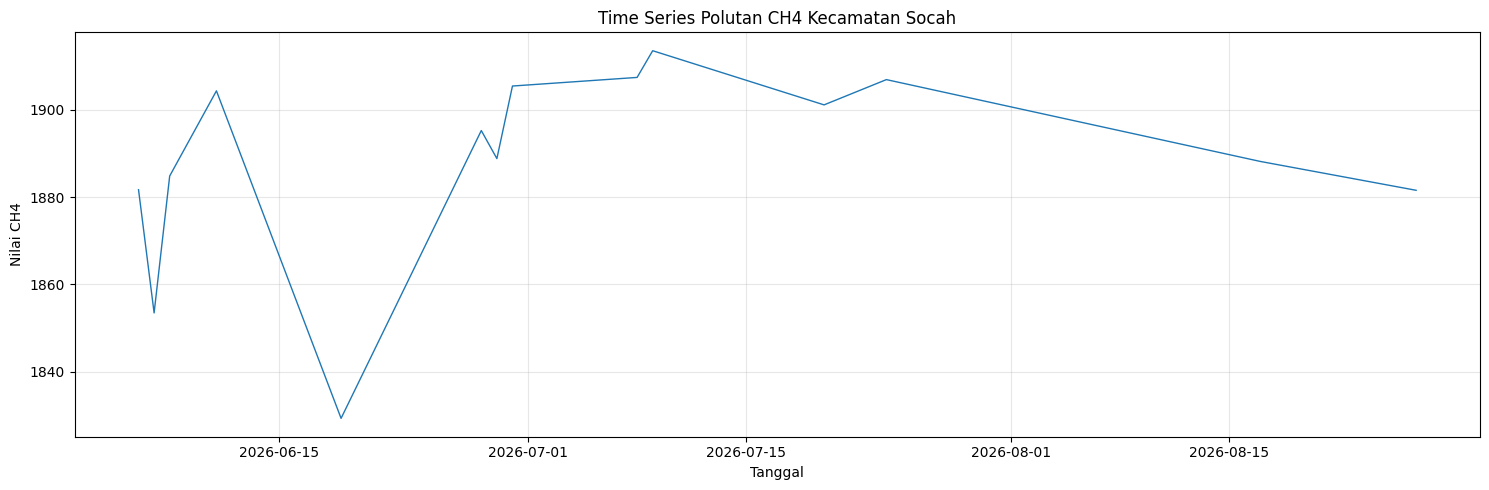

In [ ]:
plot_time_series(
    ch4_df,
    "CH4"
)

## 4. Grafik outlier


Deteksi outlier dilakukan untuk mengetahui apakah terdapat nilai polutan yang memiliki perbedaan cukup jauh dibandingkan sebagian besar data.

Metode yang digunakan adalah **IQR (Interquartile Range)**. Batas bawah dan batas atas dihitung berdasarkan kuartil pertama (Q1), kuartil ketiga (Q3), dan nilai IQR.

Nilai yang berada di luar batas tersebut ditandai sebagai kemungkinan outlier. Outlier tidak langsung dianggap sebagai kesalahan data karena dapat menunjukkan adanya perubahan atau kondisi tertentu pada waktu pengamatan.

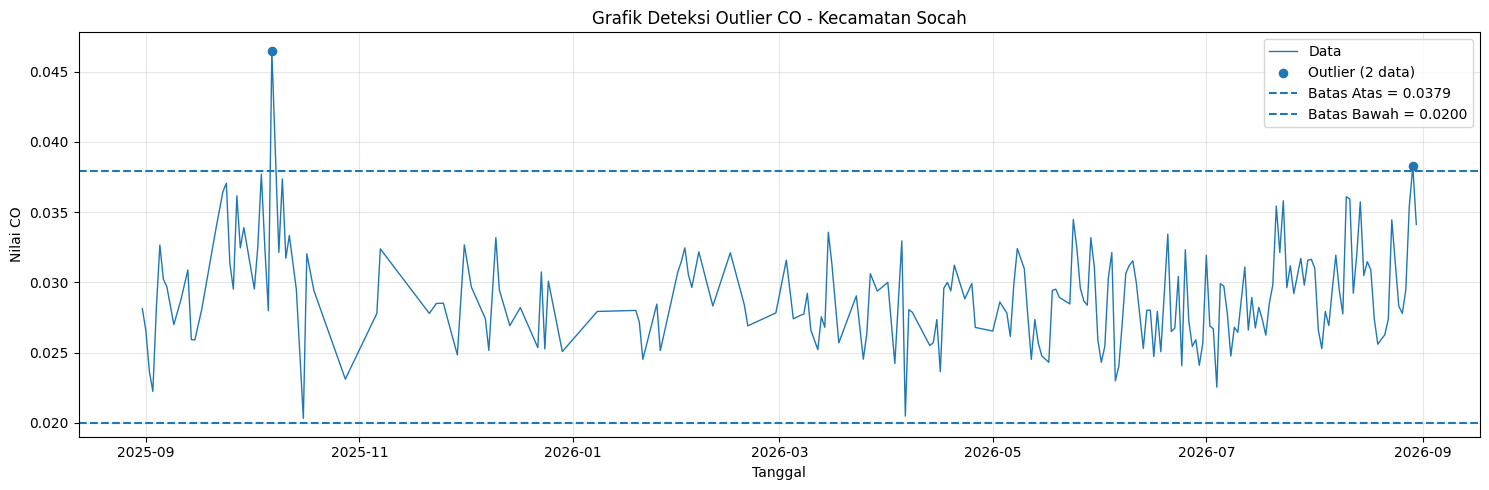


OUTLIER CO
Q1             : 0.026721235675116348
Q3             : 0.0311982321242491
IQR            : 0.004476996449132752
Batas bawah    : 0.02000574100141722
Batas atas     : 0.03791372679794823
Jumlah outlier : 2


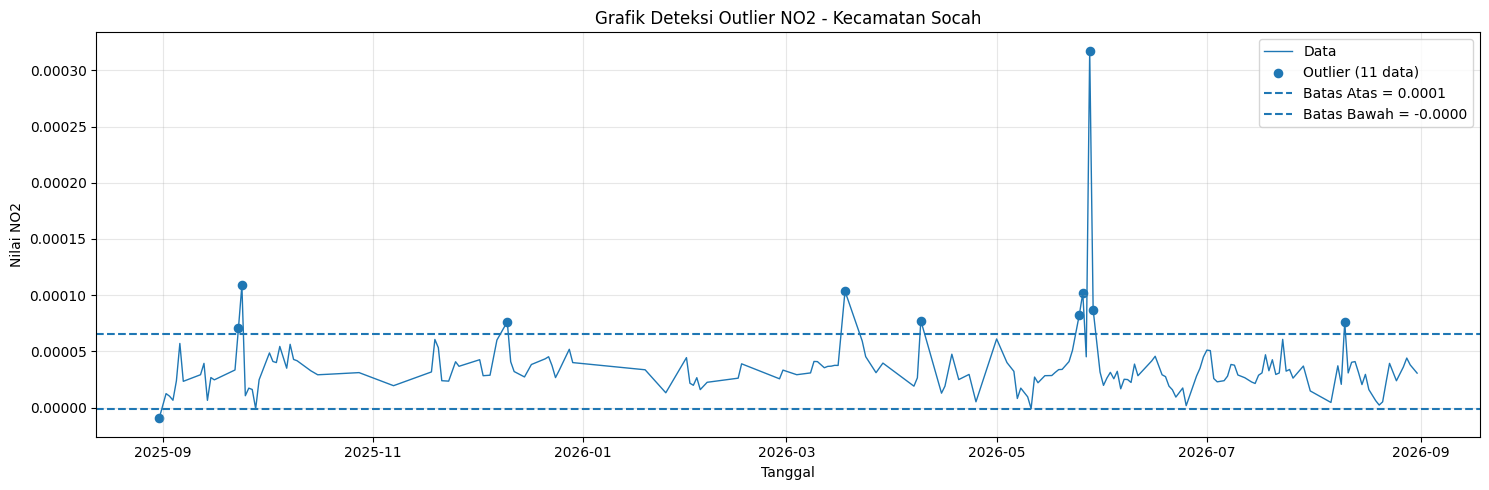


OUTLIER NO2
Q1             : 2.369444003610018e-05
Q3             : 4.0357008856517496e-05
IQR            : 1.6662568820417317e-05
Batas bawah    : -1.299413194525794e-06
Batas atas     : 6.535086208714347e-05
Jumlah outlier : 11


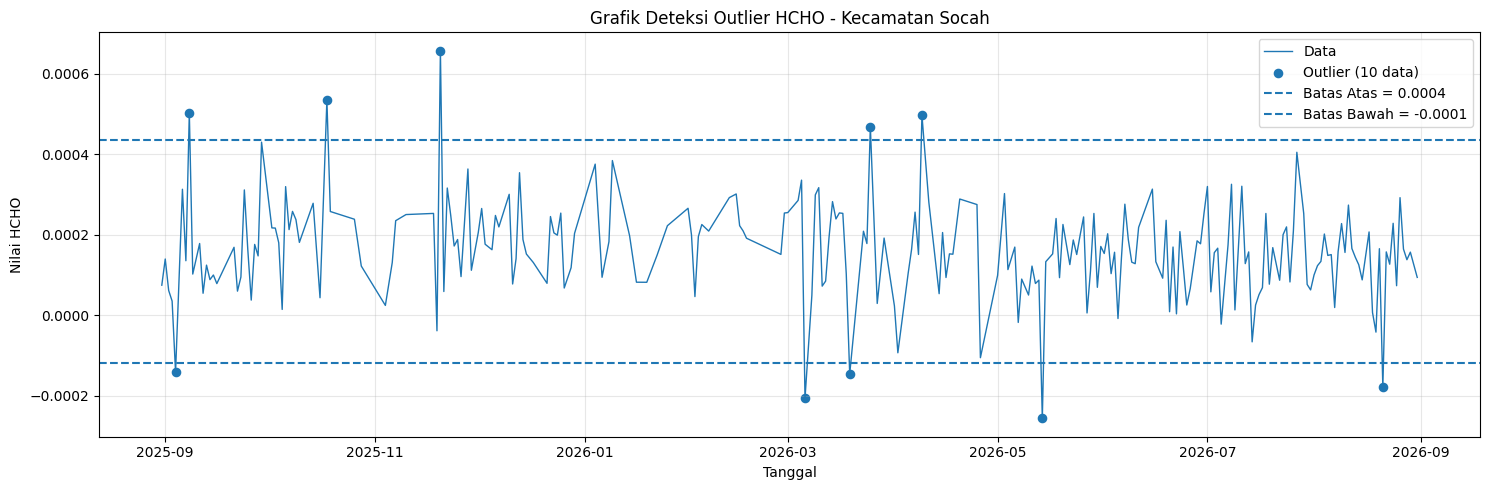


OUTLIER HCHO
Q1             : 8.947883573758493e-05
Q3             : 0.000228086777497
IQR            : 0.0001386079417594151
Batas bawah    : -0.0001184330769015377
Batas atas     : 0.00043599869013612267
Jumlah outlier : 10


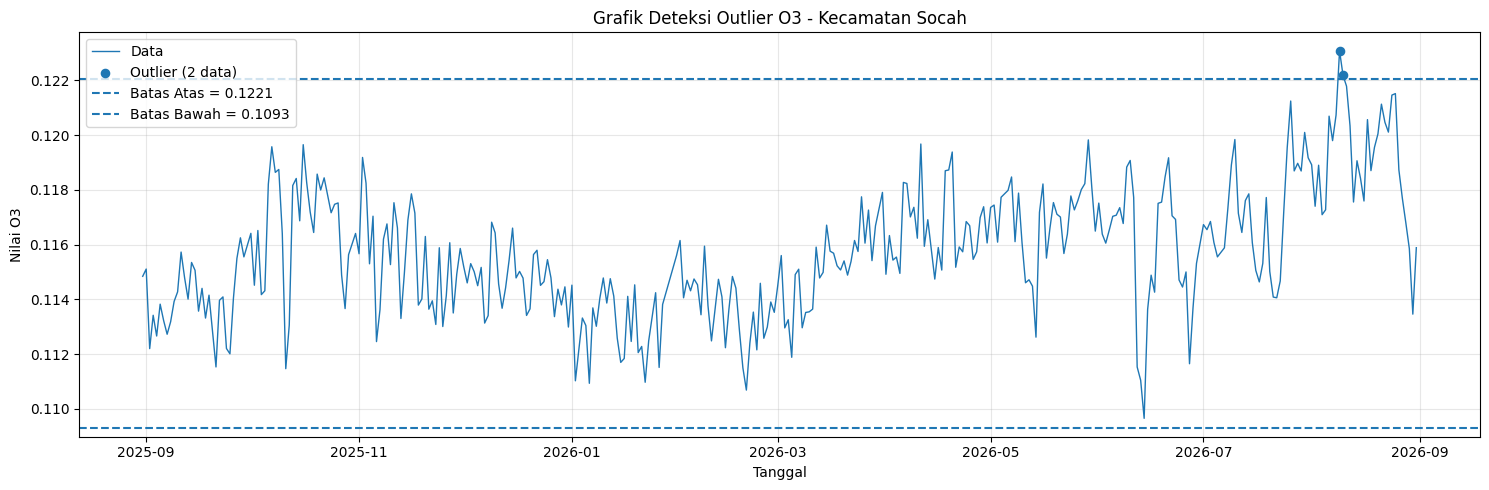


OUTLIER O3
Q1             : 0.1140868353346983
Q3             : 0.1172730276981989
IQR            : 0.003186192363500609
Batas bawah    : 0.10930754678944737
Batas atas     : 0.12205231624344981
Jumlah outlier : 2


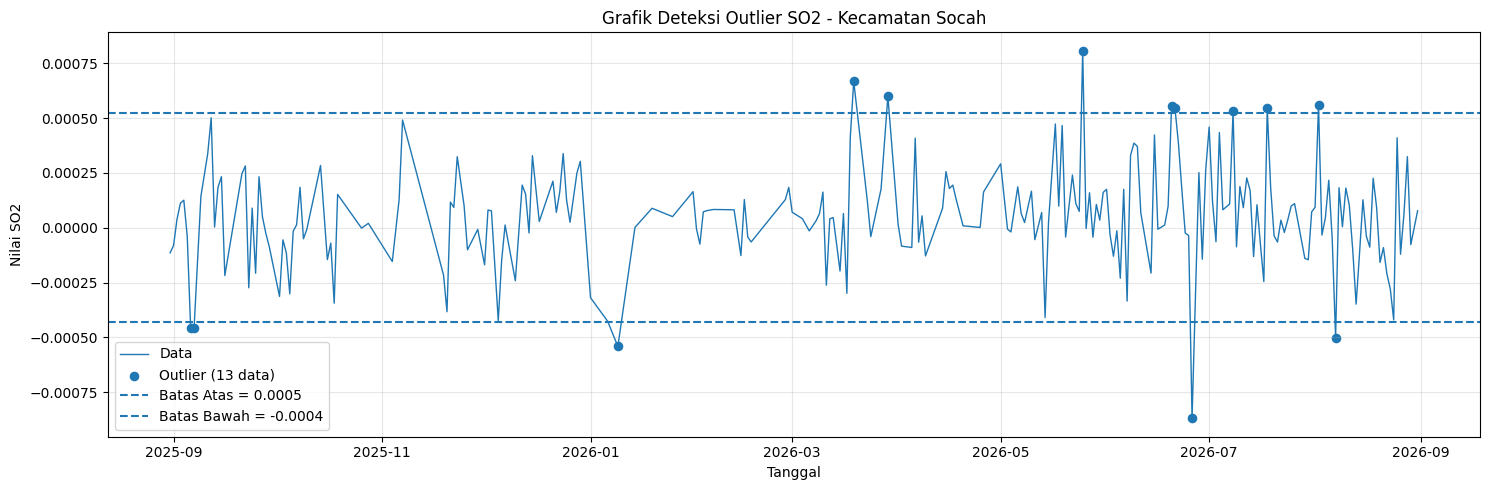


OUTLIER SO2
Q1             : -7.111287959560286e-05
Q3             : 0.0001674919303695
IQR            : 0.00023860480996510286
Batas bawah    : -0.00042902009454325713
Batas atas     : 0.0005253991453171543
Jumlah outlier : 13


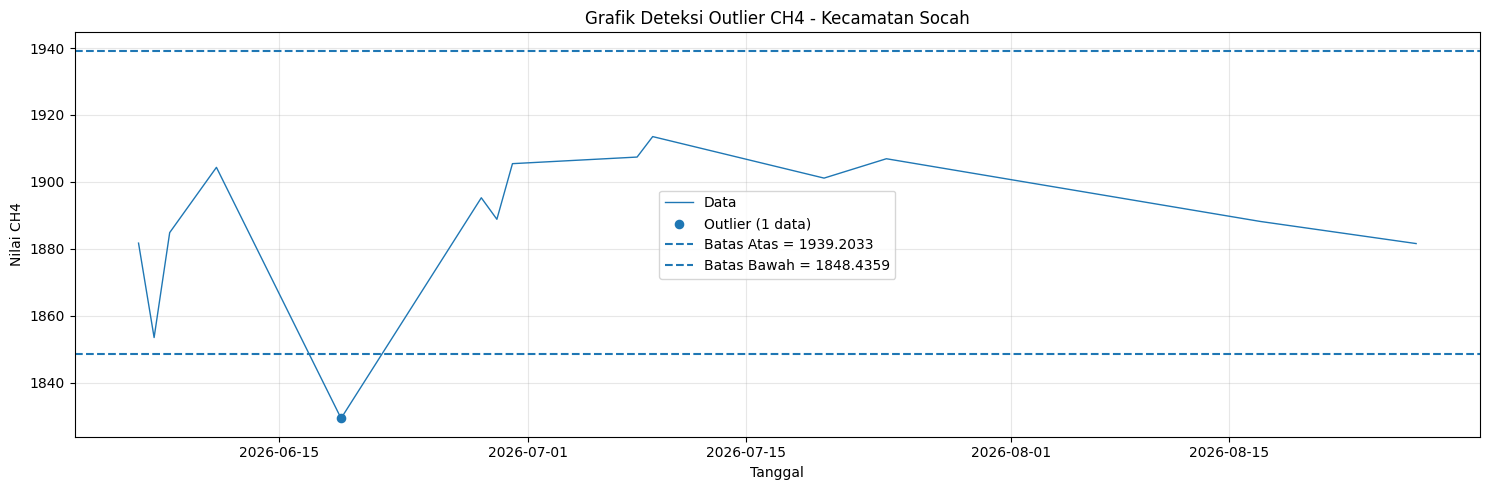


OUTLIER CH4
Q1             : 1882.473653157552
Q3             : 1905.1655171712239
IQR            : 22.691864013671875
Batas bawah    : 1848.4358571370442
Batas atas     : 1939.2033131917317
Jumlah outlier : 1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# BACA DATA
df = pd.read_csv("hasil_socah/pollutant_data_socah.csv")

# Pastikan tanggal menjadi datetime
df["date"] = pd.to_datetime(df["date"])

POLLUTANTS = [
    "CO",
    "NO2",
    "HCHO",
    "O3",
    "SO2",
    "CH4"
]

# GRAFIK OUTLIER
for polutan in POLLUTANTS:

    data = df[["date", polutan]].dropna().copy()

    # Q1 dan Q3
    Q1 = data[polutan].quantile(0.25)
    Q3 = data[polutan].quantile(0.75)

    # IQR
    IQR = Q3 - Q1

    # Batas outlier
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Ambil outlier
    outliers = data[
        (data[polutan] < lower_bound) |
        (data[polutan] > upper_bound)
    ]

    # PLOT
    plt.figure(figsize=(15, 5))

    # Data utama
    plt.plot(
        data["date"],
        data[polutan],
        linewidth=1,
        label="Data"
    )

    # Titik outlier
    plt.scatter(
        outliers["date"],
        outliers[polutan],
        marker="o",
        s=35,
        label=f"Outlier ({len(outliers)} data)"
    )

    # Batas atas
    plt.axhline(
        upper_bound,
        linestyle="--",
        label=f"Batas Atas = {upper_bound:.4f}"
    )

    # Batas bawah
    plt.axhline(
        lower_bound,
        linestyle="--",
        label=f"Batas Bawah = {lower_bound:.4f}"
    )

    plt.title(
        f"Grafik Deteksi Outlier {polutan} - Kecamatan Socah"
    )

    plt.xlabel("Tanggal")
    plt.ylabel(f"Nilai {polutan}")

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # INFORMASI OUTLIER
    print("\n" + "=" * 60)
    print(f"OUTLIER {polutan}")
    print("=" * 60)
    print("Q1             :", Q1)
    print("Q3             :", Q3)
    print("IQR            :", IQR)
    print("Batas bawah    :", lower_bound)
    print("Batas atas     :", upper_bound)
    print("Jumlah outlier :", len(outliers))

## 5. Memasukkan data ke aiven

In [ ]:
# membaca ulang CSV pollutant_data_manado.csv, lalu mengunggahnya ke basis data PostgreSQL (Aiven)
import pandas as pd
from sqlalchemy import create_engine
from google.colab import userdata

df_baru = pd.read_csv("hasil_socah/pollutant_data_socah.csv")

AIVEN_USER     = userdata.get("AIVEN_USER")
AIVEN_PASSWORD = userdata.get("AIVEN_PASSWORD")
AIVEN_HOST     = userdata.get("AIVEN_HOST")
AIVEN_PORT     = userdata.get("AIVEN_PORT")
AIVEN_DB       = userdata.get("AIVEN_DB")

db_url = f"postgresql+psycopg2://{AIVEN_USER}:{AIVEN_PASSWORD}@{AIVEN_HOST}:{AIVEN_PORT}/{AIVEN_DB}?sslmode=require"
engine = create_engine(db_url)

df_baru.to_sql("data_polutan", engine, if_exists="replace", index=False)

print(f"Berhasil! {len(df_baru)} baris terupload ke Aiven.")
print(pd.read_sql('SELECT * FROM "data_polutan" LIMIT 5', engine))

Berhasil! 356 baris terupload ke Aiven.
         date        CO       NO2      HCHO        O3       SO2   CH4
0  2025-08-31  0.028127 -0.000010  0.000074  0.114844 -0.000114  None
1  2025-09-01  0.026580       NaN  0.000139  0.115109 -0.000081  None
2  2025-09-02  0.023676  0.000012  0.000061  0.112202  0.000038  None
3  2025-09-03  0.022243  0.000010  0.000035  0.113420  0.000112  None
4  2025-09-04  0.028168  0.000006 -0.000142  0.112663  0.000126  None


# ANALISIS DATA TIME SERIES POLUTAN KECAMATAN SOCAH MENGGUNAKAN POSTGRESQL AIVEN DAN KNIME

## 1. Pendahuluan

Data polutan merupakan data yang dapat digunakan untuk mengetahui kondisi dan perubahan kualitas udara pada suatu wilayah. Dalam tugas ini digunakan data polutan di kecamatan socah yang berbentuk time series, yaitu data yang dicatat berdasarkan waktu atau tanggal tertentu. Data yang digunakan terdiri dari beberapa jenis polutan, yaitu CO, NO2, HCHO, O3, SO2, dan CH4.

Pengolahan data dilakukan dengan memindahkan data dari file CSV ke PostgreSQL Aiven. Setelah data tersimpan di database, data tersebut kemudian ditarik ke KNIME Analytics Platform untuk dilakukan analisis statistik menggunakan Statistics Node. Analisis ini bertujuan untuk mengetahui karakteristik dari masing-masing fitur polutan berdasarkan nilai minimum, maksimum, rata-rata, median, standar deviasi, skewness, kurtosis, dan jumlah data yang kosong.

## 2. Tujuan

Tujuan dari kegiatan ini adalah:
1. Memindahkan data time series polutan dari CSV ke PostgreSQL Aiven.
2. Menghubungkan PostgreSQL Aiven dengan KNIME.
3. Menarik data polutan dari database ke KNIME.
4. Melakukan analisis statistik terhadap setiap fitur polutan.
5. Mengetahui karakteristik dan penyebaran data dari CO, NO2, HCHO, O3, SO2, dan CH4.
6. Menjelaskan rumus dan contoh perhitungan statistik yang digunakan.


## 3. Data yang Digunakan

Data yang digunakan merupakan data polutan kecamatan socah. Berdasarkan data yang telah diolah, terdapat 364 baris data dengan tujuh kolom utama, yaitu:
| Kolom | Keterangan         |
| ----- | ------------------ |
| date  | Tanggal pengamatan |
| CO    | Karbon monoksida   |
| NO2   | Nitrogen dioksida  |
| HCHO  | Formaldehida       |
| O3    | Ozon               |
| SO2   | Sulfur dioksida    |
| CH4   | Metana             |

Kolom date digunakan sebagai penanda waktu, sedangkan CO, NO2, HCHO, O3, SO2, dan CH4 digunakan sebagai fitur yang dianalisis.

## 4. Memindahkan Data ke PostgreSQL Aiven

Tahap pertama adalah membaca file CSV menggunakan Python. Data kemudian dimasukkan ke dalam database PostgreSQL yang dibuat menggunakan Aiven.

## 5. Menarik Data dari Aiven ke KNIME

Setelah data berhasil disimpan di Aiven, tahap selanjutnya adalah menghubungkan database tersebut dengan KNIME.

Workflow yang digunakan adalah:

PostgreSQL Connector --> DB Table Selector --> DB Reader --> Statistics

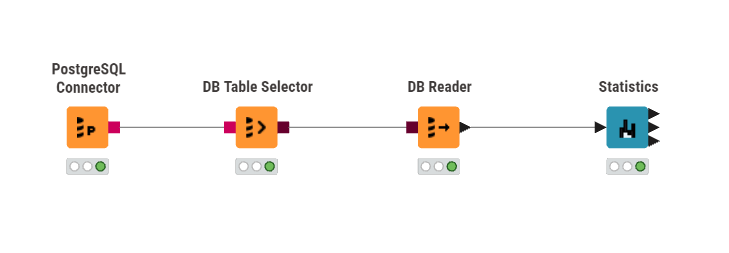

* PostgreSQL Connector

  Node PostgreSQL Connector digunakan untuk membuat koneksi antara KNIME dengan database PostgreSQL yang berada di Aiven. Pada tahap ini diperlukan informasi seperti host, port, database, username, dan password.

  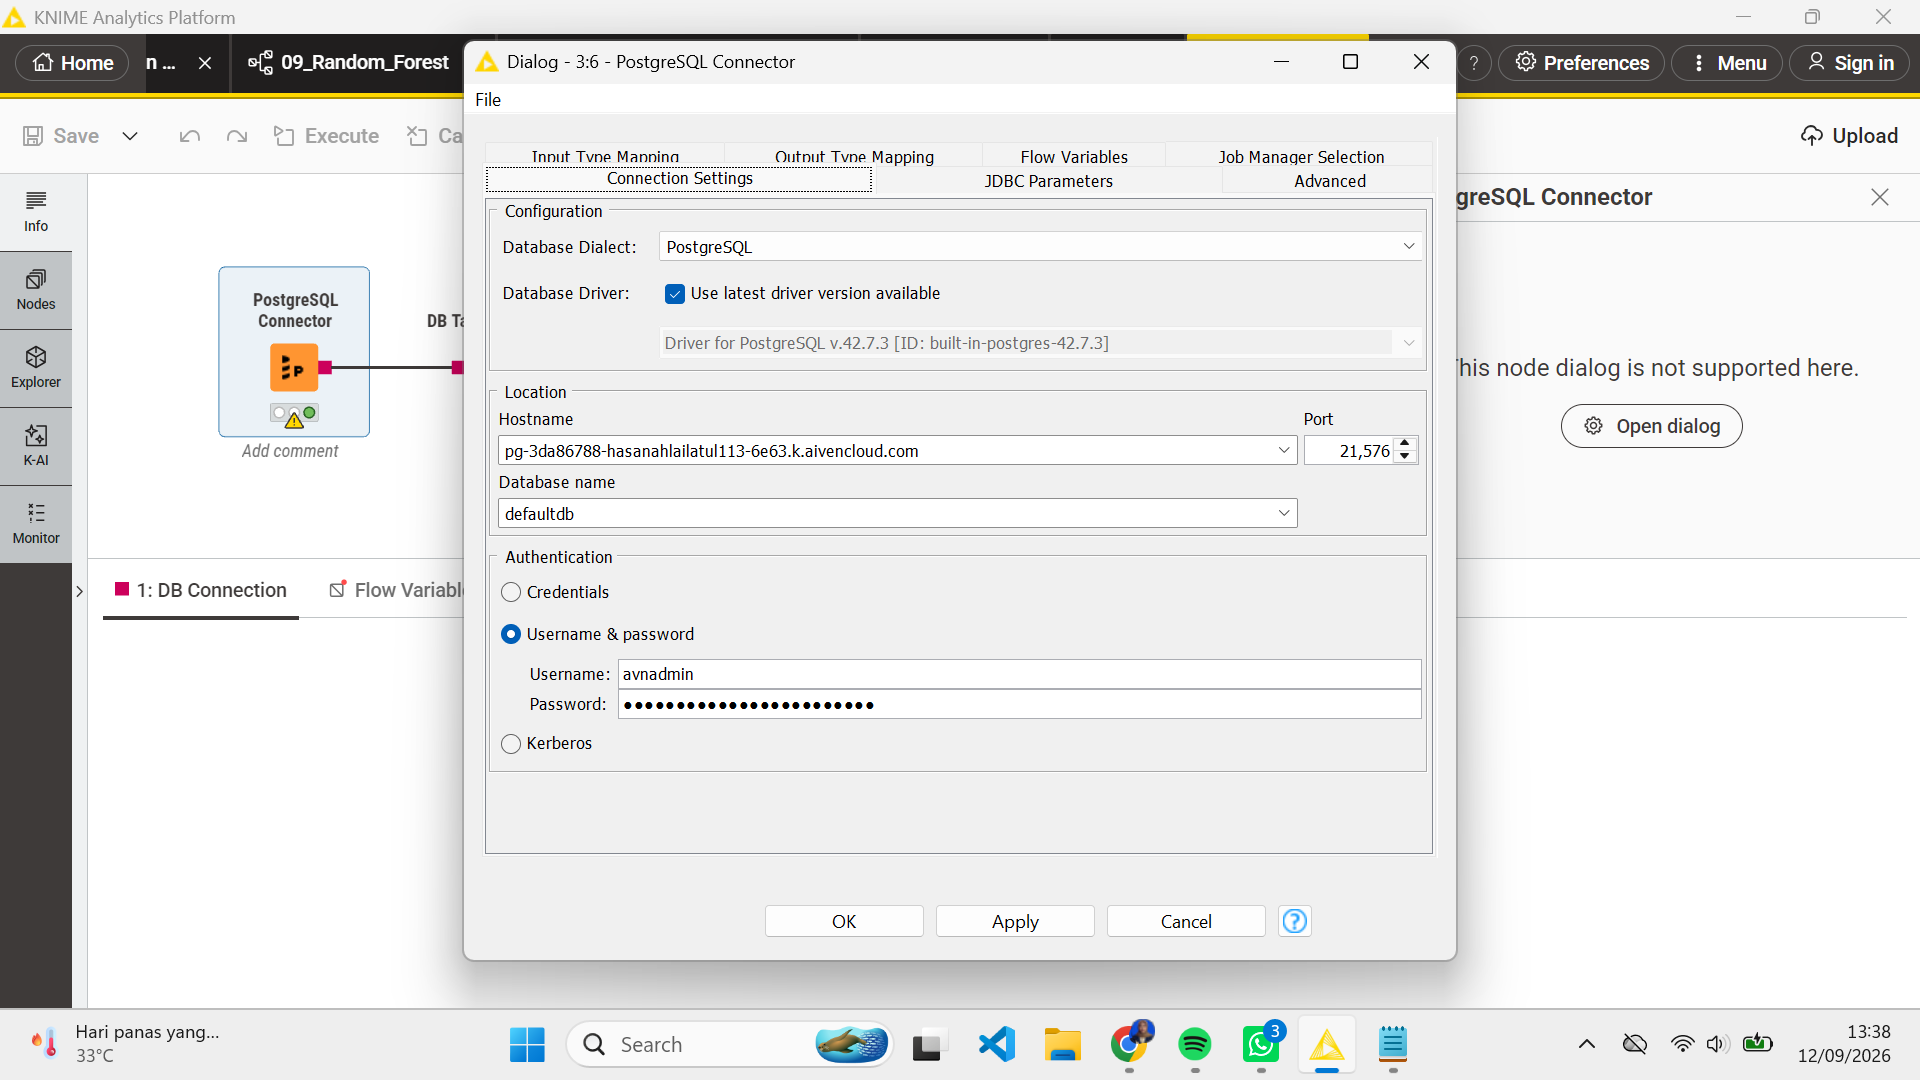



* DB Table Selector
  Node DB Table Selector digunakan untuk menentukan tabel yang akan digunakan. Tabel yang dipilih adalah: data_polutan

  Schema yang digunakan adalah: public

  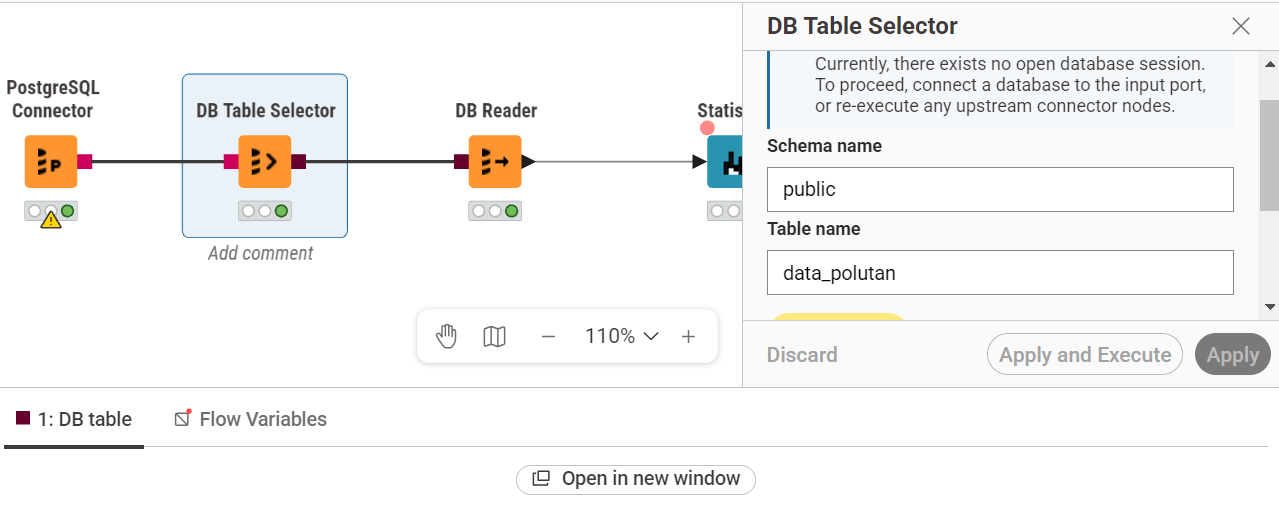

* DB Reader
  Node DB Reader digunakan untuk mengambil data dari tabel PostgreSQL dan memasukkannya ke dalam workflow KNIME sebagai data table.

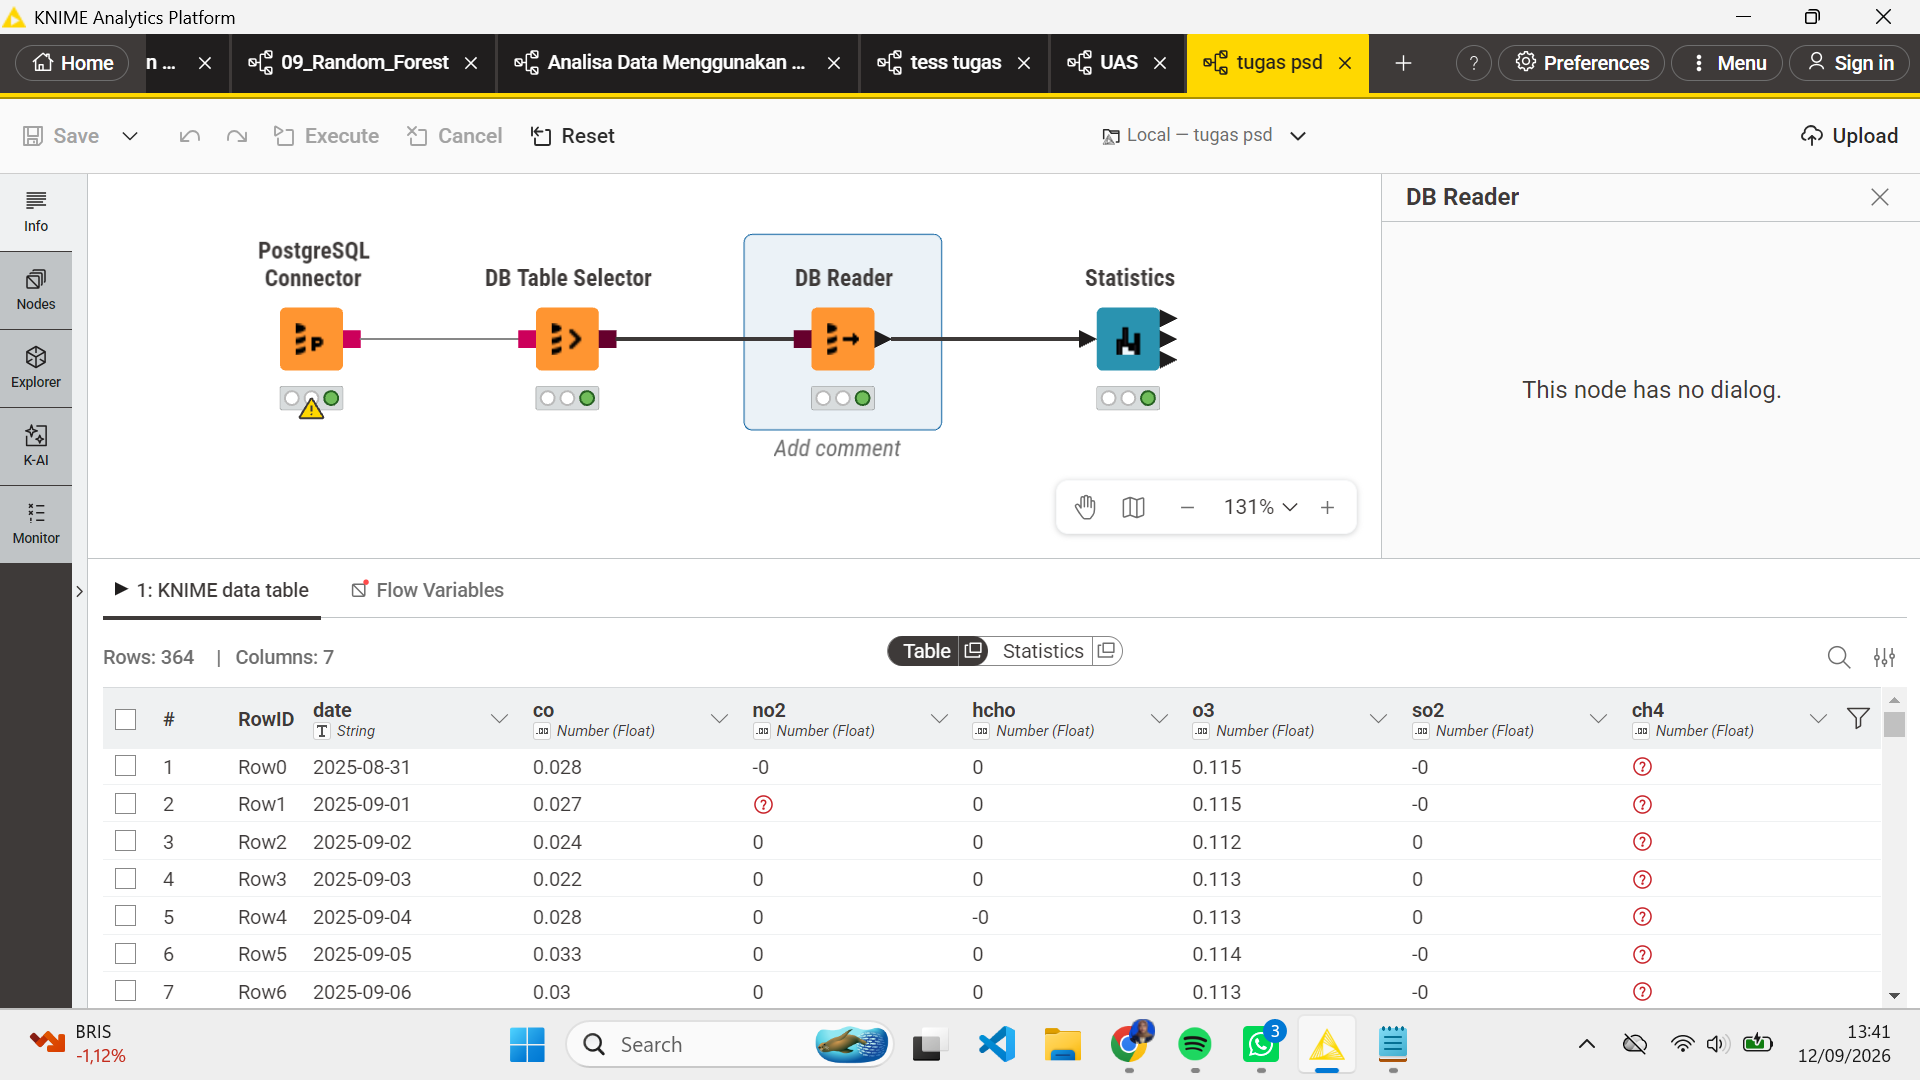

* Statistics
  Setelah data berhasil dibaca, data diteruskan ke Statistics Node. Node ini digunakan untuk mengetahui ringkasan statistik dari setiap fitur numerik.

  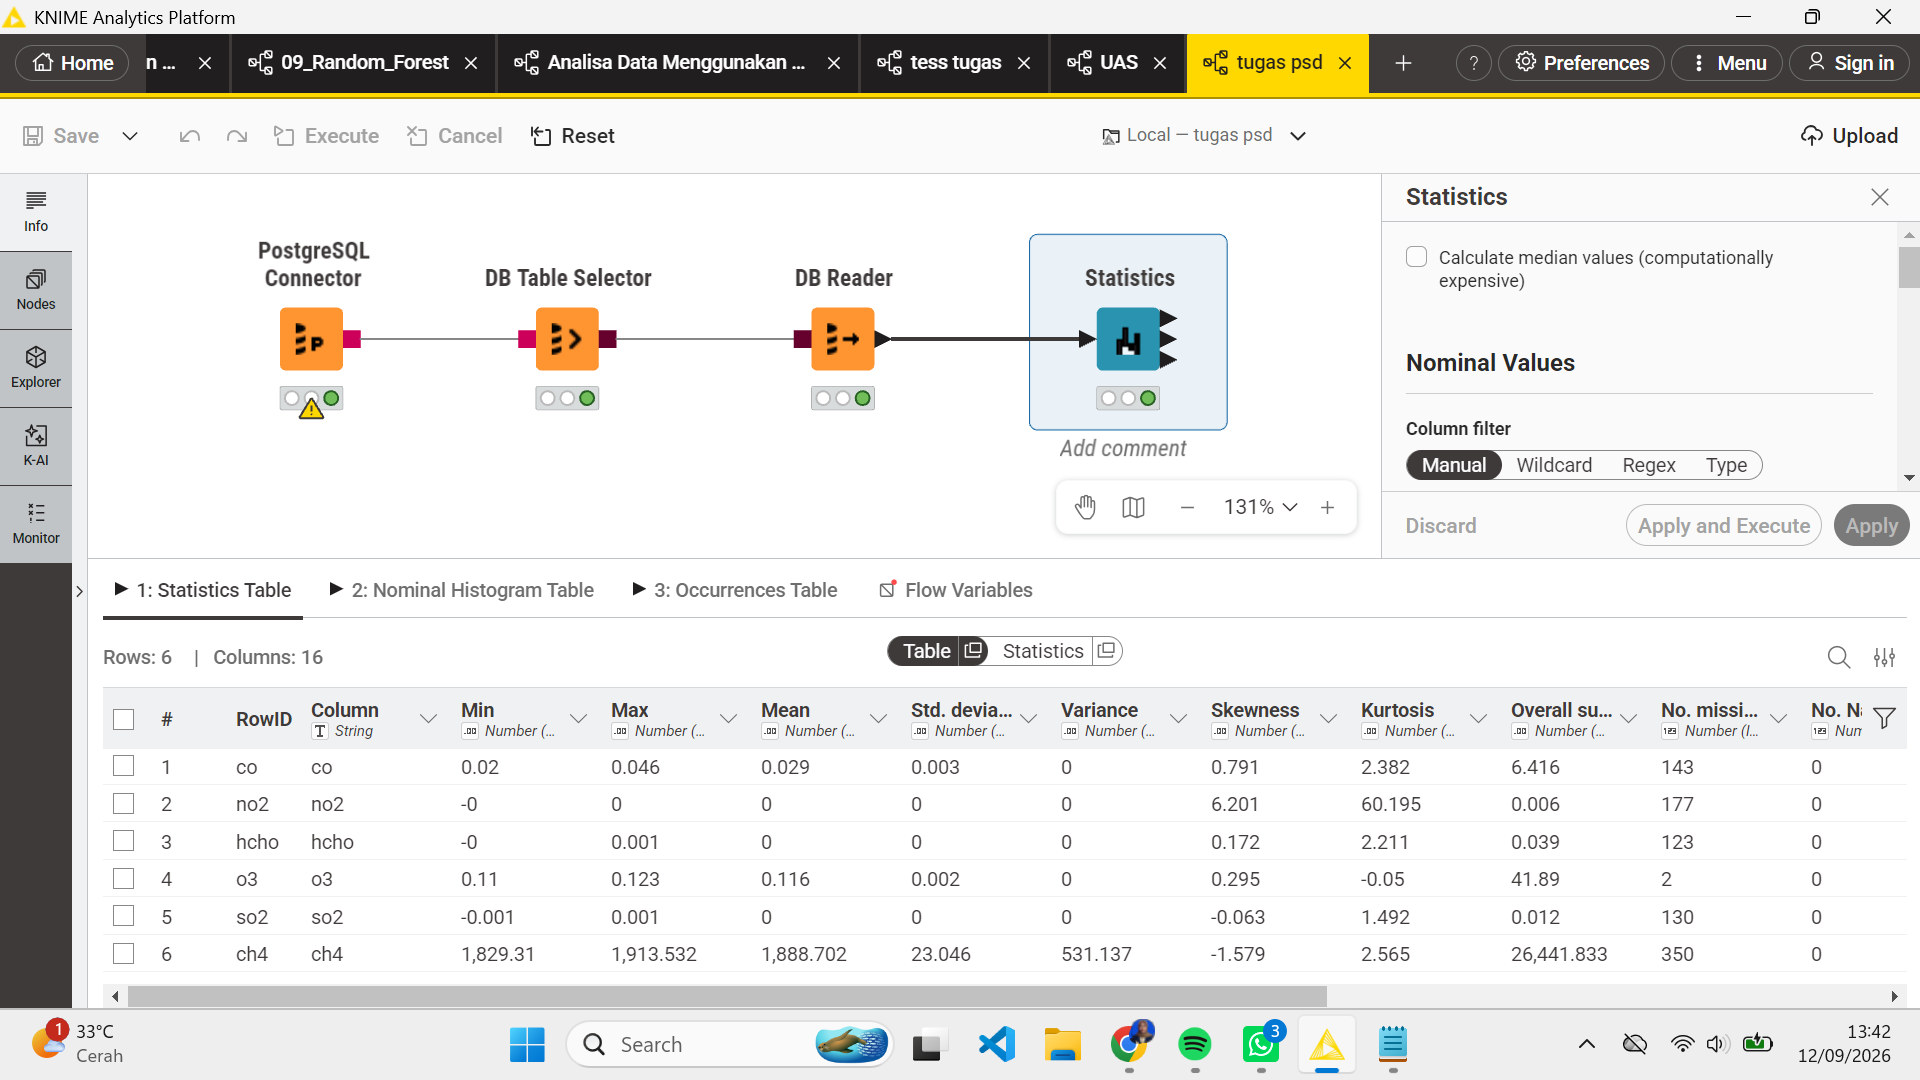



## 6. Analisis Statistik
Setelah data polutan berhasil ditarik dari PostgreSQL Aiven menggunakan PostgreSQL Connector, DB Table Selector, dan DB Reader, data kemudian dianalisis menggunakan Statistics Node pada KNIME. Analisis statistik digunakan untuk mengetahui karakteristik dari setiap fitur yang terdapat pada dataset.

Dataset yang digunakan adalah data polutan Kecamatan Socah dengan periode 31 Agustus 2025 sampai 31 Agustus 2026. Dataset terdiri dari fitur CO, NO2, HCHO, O3, SO2, dan CH4, dengan jumlah keseluruhan 364 baris data

Sebagai contoh perhitungan manual, digunakan 5 data pertama O3.
| Tanggal    |           O₃ |
| ---------- | -----------: |
| 31/08/2025 | 0,1148444439 |
| 01/09/2025 | 0,1151092251 |
| 02/09/2025 | 0,1122023140 |
| 03/09/2025 | 0,1134202903 |
| 04/09/2025 | 0,1126629015 |


### 6.1 Minimum (Min)

Minimum merupakan nilai paling rendah yang terdapat dalam suatu fitur.

Rumus:

$$ Min(X)=\min(x_1,x_2,...,x_n) $$

Dari lima data O₃:

$$ Min(O3)=\min(0,1148444439;0,1151092251;0,1122023140;0,1134202903;0,1126629015) $$

$$ Min(O3)=0,1122023140 $$

Jadi, nilai O₃ terendah dari lima data tersebut adalah 0,1122023140.


### 6.2 Maximum (Max)

Maximum merupakan nilai paling tinggi yang terdapat dalam suatu fitur.

Rumus:

$$ Max(X)=\max(x_1,x_2,...,x_n) $$

Perhitungannya:

$$ Max(O3)=\max(0,1148444439;0,1151092251;0,1122023140;0,1134202903;0,1126629015) $$

$$ Max(O3)=0,1151092251 $$

Jadi, nilai O₃ tertinggi adalah 0,1151092251.

### 6.3 Mean

Mean merupakan nilai rata-rata dari seluruh data.

Rumus:

$$ Mean=\frac{\sum x_i}{n} $$

Menggunakan lima data O₃ pertama:

$$ Mean= \frac{ 0,1148444439+ 0,1151092251+ 0,1122023140+ 0,1134202903+ 0,1126629015 }{5} $$

$$ Mean=\frac{0,5682391748}{5} $$

$$ Mean=0,1136478350 $$

Jadi, rata-rata dari lima data O₃ adalah sekitar 0,1136478350.


### 6.4 Standard Deviation

Standard deviation atau standar deviasi digunakan untuk mengetahui seberapa jauh nilai data menyebar dari nilai rata-ratanya.

Rumus:

$$ s=\sqrt{\frac{\sum(x_i-\bar{x})^2}{n-1}} $$

Diketahui:

$$ \bar{x}=0,1136478350 $$

Contoh perhitungannya:

$$ s= \sqrt{ \frac{ (0,1148444439-0,1136478350)^2+ (0,1151092251-0,1136478350)^2+ \cdots }{ 5-1 } } $$

Hasil perhitungan:
$$ s≈0,00129218 $$

Jadi, standar deviasi dari lima data O₃ adalah sekitar 0,00129218.


### 6.5 Variance

Variance atau varians merupakan ukuran penyebaran data yang diperoleh dari kuadrat standar deviasi.

Rumus:

$$ Variance=s^2 $$

Dari hasil standar deviasi:

$$ Variance=(0,00129218)^2 $$ $$ Variance\approx0,00000166973 $$

Jadi, variance dari lima data O₃ adalah sekitar 0,00000166973.


### 6.6 Skewness

Skewness digunakan untuk mengetahui bentuk kemiringan distribusi data.

Rumus sederhana:

$$ Skewness= \frac{1}{n} \sum \left( \frac{x_i-\bar{x}}{s} \right)^3 $$

Interpretasinya:
* Skewness mendekati 0 → distribusi relatif simetris.
* Skewness positif → distribusi cenderung menceng ke kanan.
* Skewness negatif → distribusi cenderung menceng ke kiri.

Menggunakan lima data O₃ pertama, nilai skewness sekitar:

$$ Skewness≈0,1635 $$

Karena nilainya positif dan cukup dekat dengan 0, maka distribusi lima data O₃ tersebut sedikit menceng ke kanan tetapi relatif mendekati simetris.


### 6.7 Kurtosis

Kurtosis digunakan untuk mengetahui bentuk distribusi dan kecenderungan data memiliki nilai yang jauh dari pusat distribusinya.

Rumus:

$$ Kurtosis= \frac{1}{n} \sum \left( \frac{x_i-\bar{x}}{s} \right)^4 $$

Untuk contoh lima data O₃, apabila menggunakan excess kurtosis seperti yang umum ditampilkan pada perangkat statistik:

$$ Kurtosis\approx-2,6551 $$

Nilai tersebut menunjukkan bahwa lima data contoh O₃ memiliki distribusi yang relatif datar dibandingkan distribusi normal.


### 6.8 Overall Sum

Overall Sum merupakan jumlah seluruh nilai yang terdapat pada suatu fitur.

Rumus:

$$ Sum=\sum_{i=1}^{n}x_i $$

Menggunakan lima data O₃:

$$ Sum= 0,1148444439+ 0,1151092251+ 0,1122023140+ 0,1134202903+ 0,1126629015 $$ $$ Sum=0,5682391748 $$

Jadi, jumlah lima data O₃ adalah sekitar 0,5682391748.


### 6.9 No. Missing Values

No. Missing Values menunjukkan jumlah data yang tidak memiliki nilai.

Rumus:

$$ Missing\ Value= Jumlah\ Data-Jumlah\ Data\ Terisi $$

Berdasarkan data CSV yang digunakan, jumlah baris adalah 364.

Untuk O₃ terdapat 2 missing value.

Maka:

$$ Missing\ Value=2 $$

Jumlah data O₃ yang terisi:

$$ 364-2=362 $$

Jadi, terdapat 362 data O₃ yang memiliki nilai dan 2 data yang kosong.

Untuk fitur lainnya:

| Fitur | Jumlah Data | Missing |
| ----- | ----------: | ------: |
| CO    |         364 |     143 |
| NO2   |         364 |     177 |
| HCHO  |         364 |     123 |
| O3    |         364 |       2 |
| SO2   |         364 |     130 |
| CH4   |         364 |     364 |

Data tersebut menunjukkan bahwa CH4 seluruhnya masih kosong, sehingga perlu dilakukan imputasi sebelum proses ekstraksi fitur.

### 6.10 No. NaNs

No. NaNs menunjukkan jumlah nilai NaN (Not a Number) yang terdapat pada suatu fitur.

Rumus:

$$ No.\ NaNs=Jumlah\ nilai\ NaN $$

Pada data yang digunakan, nilai kosong diperlakukan sebagai missing value, sedangkan tidak terdapat nilai khusus yang terbaca sebagai NaN terpisah.

Sehingga:

$$ No.\ NaNs=0 $$

Artinya, tidak ditemukan nilai NaN yang terpisah dari missing value pada data.


### 6.11 No. +∞s

No. +∞s menunjukkan jumlah data yang memiliki nilai positif tak hingga atau +∞.

Rumus:

$$ No.\ +\infty s=Jumlah\ nilai\ (+\infty) $$

Pada data polutan:

$$ No.\ +\infty s=0 $$

Artinya, tidak terdapat nilai +∞ pada dataset.


### 6.12 No. −∞s

No. −∞s menunjukkan jumlah data yang memiliki nilai negatif tak hingga atau −∞.

Rumus:

$$ No.\ -\infty s=Jumlah\ nilai\ (-\infty) $$

Pada dataset:

$$ No.\ -\infty s=0 $$

Artinya, tidak terdapat nilai −∞ pada dataset.


### 6.13 Median

Median merupakan nilai tengah setelah data diurutkan dari nilai terkecil sampai terbesar.

Jika jumlah data ganjil:

$$ Median=X_{\frac{n+1}{2}} $$

Jika jumlah data genap:

$$ Median= \frac{ X_{\frac{n}{2}}+ X_{\frac{n}{2}+1} }{2} $$

Untuk contoh lima data O₃:

Data setelah diurutkan:

0,1122023140

0,1126629015

0,1134202903

0,1148444439

0,1151092251

Karena jumlah data:

$$ n=5 $$

Maka posisi median:

$$ \frac{5+1}{2}=3 $$

Data ke-3 adalah:

$$ Median(O3)=0,1134202903 $$

Jadi, median dari lima data O₃ adalah 0,1134202903.


### 6.14 Row Count

Row Count menunjukkan jumlah keseluruhan baris data yang dianalisis.

Dataset yang digunakan memiliki:

$$ Row\ Count=364 $$

Artinya terdapat 364 baris data yang masuk ke proses analisis statistik.

Meskipun terdapat missing value pada beberapa fitur, jumlah baris keseluruhan tetap 364.

Sebagai contoh pada O₃:

$$ 364-2=362 $$

Artinya dari 364 baris, terdapat 362 nilai O₃ yang terisi dan 2 nilai yang kosong.



## 7. Ekstraksi Fitur Time Series dengan TSFEL (Kolom NO2)

TSFEL (Time Series Feature Extraction Library) digunakan untuk mengekstraksi karakteristik atau fitur dari data time series konsentrasi NO₂ di Kecamatan Socah. Sebelum ekstraksi, data dibersihkan dengan mengubah nilai yang tidak valid menjadi NaN, mendeteksi outlier menggunakan metode IQR, dan mengisi nilai yang kosong menggunakan interpolasi berdasarkan waktu. Setelah data bersih, TSFEL digunakan untuk menghitung 68 fitur yang mencakup fitur statistik, perubahan sinyal, frekuensi, energi, serta kompleksitas data.

In [ ]:
!pip install tsfel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 51.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('hasil_socah/pollutant_data_socah.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# ---------- 2. Polutan yang akan diproses ----------
POLLUTANTS = ['NO2', 'CO', 'SO2']

# ---------- 3. Daftar fitur TSFEL ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


# ---------- 4. Fungsi mengubah hasil menjadi satu nilai ----------
def to_scalar(result):

    if isinstance(result, dict) and "values" in result:
        result = result["values"]

    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))

    return float(result)


# ---------- 5. Fungsi ekstraksi satu fitur ----------
def extract_one(fn_name, signal, fs):

    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters

    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)

    return to_scalar(result)


# ---------- 6. Proses setiap polutan ----------
fs = 1

for target_pollutant in POLLUTANTS:

    print("\n========================================")
    print(f"Memproses polutan: {target_pollutant}")
    print("========================================")

    # Pastikan numerik
    df[target_pollutant] = pd.to_numeric(
        df[target_pollutant],
        errors='coerce'
    )

    # ---------- Missing awal ----------
    n_missing_before = df[target_pollutant].isna().sum()

    persen_missing_before = (
        n_missing_before / len(df)
    ) * 100

    print(
        f"Missing awal: {n_missing_before} data "
        f"({persen_missing_before:.2f}%)"
    )

    # ---------- Deteksi outlier IQR ----------
    Q1 = df[target_pollutant].quantile(0.25)
    Q3 = df[target_pollutant].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier = (
        (df[target_pollutant] < lower_bound) |
        (df[target_pollutant] > upper_bound)
    )

    jumlah_outlier = outlier.sum()

    print(f"Jumlah outlier: {jumlah_outlier}")

    # Outlier dijadikan missing
    df.loc[
        outlier,
        target_pollutant
    ] = np.nan

    # =========================================================
    # 7. TURUNKAN MISSING MENJADI 15%
    # =========================================================

    total_data = len(df)

    # Target maksimal 15%
    target_missing = round(total_data * 0.15)

    # Posisi data yang missing
    missing_index = df[
        df[target_pollutant].isna()
    ].index.tolist()

    jumlah_missing_sekarang = len(missing_index)

    print(
        f"Missing setelah outlier: "
        f"{jumlah_missing_sekarang} data"
    )

    print(
        f"Target missing 15%: "
        f"{target_missing} data"
    )

    # Jika missing lebih dari 15%,
    # isi sebagian missing menggunakan interpolasi
    if jumlah_missing_sekarang > target_missing:

        # Berapa data yang harus diisi
        jumlah_yang_diisi = (
            jumlah_missing_sekarang - target_missing
        )

        df_temp = df.set_index('date')

        # Interpolasi semua missing sementara
        df_interpolated = (
            df_temp[target_pollutant]
            .interpolate(
                method='time',
                limit_direction='both'
            )
        )

        # Pilih missing yang akan diisi
        index_diisi = missing_index[
            :jumlah_yang_diisi
        ]

        # Isi hanya sebagian missing
        df.loc[
            index_diisi,
            target_pollutant
        ] = df_interpolated.loc[
            df.loc[index_diisi, 'date']
        ].values

    # =========================================================
    # 8. CEK MISSING FINAL
    # =========================================================

    n_missing_final = df[target_pollutant].isna().sum()

    persen_missing_final = (
        n_missing_final / len(df)
    ) * 100

    print(
        f"Missing final: {n_missing_final} data "
        f"({persen_missing_final:.2f}%)"
    )

    # =========================================================
    # 9. DATA UNTUK TSFEL
    # =========================================================
    # Missing 15% tetap dipertahankan di data penelitian.
    # Untuk TSFEL, missing sementara diisi dengan interpolasi.

    df_clean = df.set_index('date')

    signal_tsfel = (
        df_clean[target_pollutant]
        .interpolate(
            method='time',
            limit_direction='both'
        )
        .ffill()
        .bfill()
    )

    signal_1d = (
        signal_tsfel
        .astype(float)
        .values
    )

    print(
        f"Data untuk TSFEL: "
        f"{len(signal_1d)} data"
    )

    # =========================================================
    # 10. EKSTRAKSI FITUR TSFEL
    # =========================================================

    row = {}

    for fn_name in FEATURE_LIST:

        try:

            row[fn_name] = extract_one(
                fn_name,
                signal_1d,
                fs
            )

        except Exception as e:

            print(
                f"Fitur {fn_name} gagal: {e}"
            )

            row[fn_name] = np.nan

    # ---------- Buat DataFrame fitur ----------
    extracted_features_final = pd.DataFrame([row])

    print(
        f"Berhasil! Jumlah fitur "
        f"{target_pollutant}: "
        f"{extracted_features_final.shape[1]}"
    )

    # ---------- Simpan hasil TSFEL ----------
    nama_file = (
        f'{target_pollutant}_socah_TSFEL.csv'
    )

    extracted_features_final.to_csv(
        nama_file,
        index=False
    )

    print(
        f"File berhasil disimpan: "
        f"{nama_file}"
    )


print("\n========================================")
print("SEMUA POLUTAN SELESAI DIPROSES")
print("========================================")

Jumlah fitur yang diminta: 68

Memproses polutan: NO2
Missing awal: 172 data (48.31%)
Jumlah outlier: 11
Missing setelah outlier: 183 data
Target missing 15%: 53 data
Missing final: 53 data (14.89%)
Data untuk TSFEL: 356 data
Berhasil! Jumlah fitur NO2: 68
File berhasil disimpan: NO2_socah_TSFEL.csv

Memproses polutan: CO
Missing awal: 137 data (38.48%)
Jumlah outlier: 2
Missing setelah outlier: 139 data
Target missing 15%: 53 data
Missing final: 53 data (14.89%)
Data untuk TSFEL: 356 data
Berhasil! Jumlah fitur CO: 68
File berhasil disimpan: CO_socah_TSFEL.csv

Memproses polutan: SO2
Missing awal: 120 data (33.71%)
Jumlah outlier: 13
Missing setelah outlier: 133 data
Target missing 15%: 53 data
Missing final: 53 data (14.89%)
Data untuk TSFEL: 356 data
Berhasil! Jumlah fitur SO2: 68
File berhasil disimpan: SO2_socah_TSFEL.csv

SEMUA POLUTAN SELESAI DIPROSES


In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features
from sklearn.linear_model import LinearRegression

# ---------- 1. Muat 1 file CSV utama yang berisi semua polutan ----------
df = pd.read_csv('hasil_socah/pollutant_data_socah.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

pollutants = ['NO2', 'SO2', 'CO']
fs = 1

# ---------- 2. Daftar PERSIS 68 fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print(f"Jumlah fitur per polutan: {len(FEATURE_LIST)}")
print(f"Total target fitur keseluruhan: {len(FEATURE_LIST) * len(pollutants)}")


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


# ---------- 3. Dictionary untuk menampung hasil, DIPISAH 2 METODE ----------
combined_row_polynomial = {}
combined_row_linreg = {}

# ---------- 4. Looping untuk membersihkan dan mengekstraksi tiap polutan ----------
for pollutant in pollutants:
    print(f"\n--- Memproses polutan: {pollutant} ---")

    df_poly = df[['date', pollutant]].copy()

    # Paksa kolom target jadi numerik
    df_poly[pollutant] = pd.to_numeric(df_poly[pollutant], errors='coerce')
    n_missing_before = df_poly[pollutant].isna().sum()
    print(f"Jumlah NaN/non-numerik pada {pollutant}: {n_missing_before}")

    # Handling outlier dengan IQR
    Q1 = df_poly[pollutant].quantile(0.25)
    Q3 = df_poly[pollutant].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_poly.loc[(df_poly[pollutant] < lower_bound) | (df_poly[pollutant] > upper_bound), pollutant] = np.nan

    n_total_nan = df_poly[pollutant].isna().sum()
    pct_nan = n_total_nan / len(df_poly) * 100
    print(f"Total NaN setelah deteksi outlier (missing + outlier): {n_total_nan} ({pct_nan:.2f}%)")
    if pct_nan > 15:
        print(f"PERINGATAN: missing+outlier {pct_nan:.2f}% melebihi batas 15%!")

    # ================== BAGIAN YANG DIUBAH: 2 METODE IMPUTASI ==================

    # ---- Metode A: Polynomial interpolation ----
    series_untuk_poly = df_poly.set_index('date')[pollutant].reset_index(drop=True)
    signal_polynomial = series_untuk_poly.interpolate(
        method='polynomial', order=2
    ).ffill().bfill().astype(float).values

    # ---- Metode B: Linear Regression (tren garis lurus dari seluruh data) ----
    series_untuk_linreg = df_poly.set_index('date')[pollutant].reset_index(drop=True)
    x_semua = np.arange(len(series_untuk_linreg)).reshape(-1, 1)
    valid_mask = series_untuk_linreg.notna()

    model = LinearRegression()
    model.fit(x_semua[valid_mask], series_untuk_linreg[valid_mask].values)
    prediksi_semua = model.predict(x_semua)

    signal_linreg = series_untuk_linreg.copy()
    signal_linreg[~valid_mask] = prediksi_semua[~valid_mask.values]
    signal_linreg = signal_linreg.astype(float).values

    # ================== AKHIR BAGIAN YANG DIUBAH ==================

    # Ekstraksi fitur dan beri prefix nama polutan, UNTUK MASING-MASING METODE
    for fn_name in FEATURE_LIST:
        feature_key = f"{pollutant}_{fn_name}"
        combined_row_polynomial[feature_key] = extract_one(fn_name, signal_polynomial, fs)
        combined_row_linreg[feature_key] = extract_one(fn_name, signal_linreg, fs)

# ---------- 5. Simpan ke DataFrame final (1 baris, 204 kolom) x 2 FILE ----------
extracted_features_polynomial = pd.DataFrame([combined_row_polynomial])
extracted_features_linreg = pd.DataFrame([combined_row_linreg])

print(f"\nBerhasil! Total kolom akhir (Polynomial): {extracted_features_polynomial.shape[1]}")
print(f"Berhasil! Total kolom akhir (Linear Regression): {extracted_features_linreg.shape[1]}")

output_filename_polynomial = 'All-Pollutants-Cerme-Polynomial-TSFEL.csv'
output_filename_linreg = 'All-Pollutants-Cerme-LinearRegression-TSFEL.csv'

extracted_features_polynomial.to_csv(output_filename_polynomial, index=False)
extracted_features_linreg.to_csv(output_filename_linreg, index=False)

print(f"File berhasil disimpan sebagai: {output_filename_polynomial}")
print(f"File berhasil disimpan sebagai: {output_filename_linreg}")


Jumlah fitur per polutan: 68
Total target fitur keseluruhan: 204

--- Memproses polutan: NO2 ---
Jumlah NaN/non-numerik pada NO2: 172
Total NaN setelah deteksi outlier (missing + outlier): 183 (51.40%)
PERINGATAN: missing+outlier 51.40% melebihi batas 15%!

--- Memproses polutan: SO2 ---
Jumlah NaN/non-numerik pada SO2: 120
Total NaN setelah deteksi outlier (missing + outlier): 133 (37.36%)
PERINGATAN: missing+outlier 37.36% melebihi batas 15%!

--- Memproses polutan: CO ---
Jumlah NaN/non-numerik pada CO: 137
Total NaN setelah deteksi outlier (missing + outlier): 139 (39.04%)
PERINGATAN: missing+outlier 39.04% melebihi batas 15%!

Berhasil! Total kolom akhir (Polynomial): 204
Berhasil! Total kolom akhir (Linear Regression): 204
File berhasil disimpan sebagai: All-Pollutants-Cerme-Polynomial-TSFEL.csv
File berhasil disimpan sebagai: All-Pollutants-Cerme-LinearRegression-TSFEL.csv


## 8. Kesimpulan

Berdasarkan proses yang telah dilakukan, data time series polutan kecamatan socah berhasil dipindahkan dari CSV ke PostgreSQL Aiven dan kemudian berhasil ditarik ke KNIME menggunakan PostgreSQL Connector, DB Table Selector, dan DB Reader. Selanjutnya, data dianalisis menggunakan Statistics Node untuk mengetahui karakteristik setiap fitur polutan. Analisis meliputi nilai minimum, maksimum, mean, standar deviasi, variance, skewness, kurtosis, overall sum, missing values, NaN, nilai tak hingga, median, row count, dan histogram. Hasil statistik menunjukkan bahwa setiap polutan memiliki karakteristik data yang berbeda serta terdapat beberapa missing value pada beberapa fitur.